In [1]:
# Cell [0] - IMPORTS & GLOBAL SETUP

import os
os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
tf.random.set_seed(42)

from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_STATE = 42

plt.style.use("seaborn-v0_8")
%matplotlib inline

In [3]:
# Cell [1] - PATH & CEK SHEET

from pathlib import Path
import pandas as pd

# Path asli laptop kamu
windows_path = Path(r"C:\Users\totti\OneDrive\Dokumen\Machine Learning\New\Gold_Silver_Forecasting - New.xlsx")

candidate_paths = [
    windows_path,  # untuk Jupyter lokal di laptop kamu
    Path("/content/Gold_Silver_Forecasting - New.xlsx"),  # untuk Google Colab
    Path("/mnt/data/Gold_Silver_Forecasting - New.xlsx"),
    Path("Gold_Silver_Forecasting - New.xlsx"),  # jika file ada di folder notebook
]

path = None
for p in candidate_paths:
    if p.exists():
        path = str(p)
        break

if path is None:
    raise FileNotFoundError(
        "Dataset tidak ditemukan. Pastikan file Excel ada di salah satu lokasi berikut:\n"
        "1. Path Windows asli kamu\n"
        "2. Folder kerja notebook\n"
        "3. Folder /content jika pakai Google Colab\n\n"
        f"Path Windows yang dicek:\n{windows_path}"
    )

print("Path file:", path)

# cek sheet yang tersedia
xls = pd.ExcelFile(path)
print("Sheet di workbook:")
print(xls.sheet_names)

Path file: C:\Users\totti\OneDrive\Dokumen\Machine Learning\New\Gold_Silver_Forecasting - New.xlsx
Sheet di workbook:
['Sheet1']


In [5]:
# Cell [2] - LOAD DATA UTAMA

df_raw = pd.read_excel(
    path,
    sheet_name=0,          # kalau perlu ganti ke nama sheet spesifik
    parse_dates=["DATE"]   # pastikan kolom tanggal bernama DATE
)

# sort berdasarkan tanggal & jadikan index
df_raw = df_raw.sort_values("DATE").set_index("DATE")

print("Shape df_raw:", df_raw.shape)
df_raw.head()


Shape df_raw: (13027, 51)


,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CLOSE,GOLD_CHANGE_%,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CLOSE,SILVER_CHANGE_%,...,REAL_YIELD,GOLD_DAILY_RANGE,GOLD_SILVER_RATIO,REAL_INTEREST_RATE,GOLD_VOLATILITY_30D,COPPER_GOLD_RATIO,WTI_GOLD_RATIO,GOLD_RSI_14,GOLD_MACD,CPI_YOY
DATE,,,,,,,,,,,,,,,,,,,,,
1990-01-01,404.85,403.05,403.05,403.05,0.83,5.21,5.22,5.21,5.22,0.97,...,3.333,0.0,77.212644,3.333,0.012172,0.002640,0.054137,33.294931,0.847403,4.6
1990-01-02,403.85,399.45,399.45,399.45,-0.89,5.18,5.19,5.18,5.19,-0.57,...,3.333,0.0,76.965318,3.333,0.012063,0.002659,0.057304,41.642651,0.210248,4.6
1990-01-03,399.60,394.75,394.75,394.75,-1.18,5.17,5.17,5.17,5.17,-0.39,...,3.333,0.0,76.353965,3.333,0.011832,0.002778,0.059987,30.694444,-0.666273,4.6
1990-01-04,399.45,399.05,399.05,399.05,1.09,5.27,5.28,5.27,5.28,2.13,...,3.333,0.0,75.577652,3.333,0.011988,0.002720,0.058664,29.915730,-1.002393,4.6
1990-01-05,407.45,406.35,406.35,406.35,1.83,5.32,5.33,5.32,5.33,0.95,...,3.333,0.0,76.238274,3.333,0.012050,0.002695,0.056798,42.535545,-0.671975,4.6


In [7]:
# Cell [3] - PILIH KOLOM PENTING & FILTERING

base_cols = [
    "GOLD_CLOSE",
    "SILVER_CLOSE",
    "WTI",
    "COPPER",
    "SP500",
    "VIX",
    "FED_FUNDS",
    "M2",
    "CPI_ACTUAL",
    "TREASURY_10Y",
    "REAL_YIELD",
    "REAL_INTEREST_RATE",
]

# hanya pakai kolom yang memang ada
base_cols_exist = [c for c in base_cols if c in df_raw.columns]
missing_cols = [c for c in base_cols if c not in df_raw.columns]

print("Kolom dipakai:", base_cols_exist)
print("Kolom TIDAK ditemukan:", missing_cols)

df_fe = df_raw[base_cols_exist].copy()

print("\nMissing per kolom:")
print(df_fe.isna().sum())

# drop baris yang ada NaN di kolom penting
df_fe = df_fe.dropna(how="any")

print("\nShape setelah drop NaN:", df_fe.shape)
df_fe.head()


Kolom dipakai: ['GOLD_CLOSE', 'SILVER_CLOSE', 'WTI', 'COPPER', 'SP500', 'VIX', 'FED_FUNDS', 'M2', 'CPI_ACTUAL', 'TREASURY_10Y', 'REAL_YIELD', 'REAL_INTEREST_RATE']
Kolom TIDAK ditemukan: []

Missing per kolom:
GOLD_CLOSE            0
SILVER_CLOSE          0
WTI                   0
COPPER                0
SP500                 0
VIX                   0
FED_FUNDS             0
M2                    0
CPI_ACTUAL            0
TREASURY_10Y          0
REAL_YIELD            0
REAL_INTEREST_RATE    0
dtype: int64

Shape setelah drop NaN: (13027, 12)


,GOLD_CLOSE,SILVER_CLOSE,WTI,COPPER,SP500,VIX,FED_FUNDS,M2,CPI_ACTUAL,TREASURY_10Y,REAL_YIELD,REAL_INTEREST_RATE
DATE,,,,,,,,,,,,
1990-01-01,403.05,5.22,21.82,1.0640,353.4,18.19,8.23,3166800000000,4.6,7.933,3.333,3.333
1990-01-02,399.45,5.19,22.89,1.0620,359.7,18.19,8.23,3166800000000,4.6,7.933,3.333,3.333
1990-01-03,394.75,5.17,23.68,1.0965,358.8,18.19,8.23,3166800000000,4.6,7.933,3.333,3.333
1990-01-04,399.05,5.28,23.41,1.0855,355.7,19.22,8.23,3166800000000,4.6,7.933,3.333,3.333
1990-01-05,406.35,5.33,23.08,1.0950,352.2,20.11,8.23,3166800000000,4.6,7.933,3.333,3.333


In [9]:
# Cell [4] - RETURN & VOLATILITY FEATURES (RET_1D)

df_ret = df_fe.copy()

# 1) Return masa lalu (level harga emas)
df_ret["RET_PAST_1"] = df_ret["GOLD_CLOSE"].pct_change(1)
df_ret["RET_PAST_3"] = df_ret["GOLD_CLOSE"].pct_change(3)
df_ret["RET_PAST_5"] = df_ret["GOLD_CLOSE"].pct_change(5)

# 2) Rolling volatility dari return harian
df_ret["VOL_5"]  = df_ret["RET_PAST_1"].rolling(window=5).std()
df_ret["VOL_20"] = df_ret["RET_PAST_1"].rolling(window=20).std()

# 3) TARGET: return 1 hari ke depan (forward)
df_ret["RET_1D"] = (df_ret["GOLD_CLOSE"].shift(-1) - df_ret["GOLD_CLOSE"]) / df_ret["GOLD_CLOSE"]

# 4) TARGET_PRICE: harga emas besok (untuk evaluasi level harga)
df_ret["TARGET_PRICE"] = df_ret["GOLD_CLOSE"].shift(-1)

# Buang baris yang mengandung NaN akibat shift/rolling
df_ret = df_ret.dropna(subset=[
    "RET_PAST_1", "RET_PAST_3", "RET_PAST_5",
    "VOL_5", "VOL_20", "RET_1D", "TARGET_PRICE"
])

print("Shape df_ret:", df_ret.shape)
df_ret.head()


Shape df_ret: (13006, 19)


,GOLD_CLOSE,SILVER_CLOSE,WTI,COPPER,SP500,VIX,FED_FUNDS,M2,CPI_ACTUAL,TREASURY_10Y,REAL_YIELD,REAL_INTEREST_RATE,RET_PAST_1,RET_PAST_3,RET_PAST_5,VOL_5,VOL_20,RET_1D,TARGET_PRICE
DATE,,,,,,,,,,,,,,,,,,,
1990-01-21,410.15,5.22,23.67,0.9930,339.1,22.50,8.23,3166800000000,4.6,8.239,3.639,3.639,0.000000,-0.001825,0.002199,0.006035,0.008763,-0.003657,408.65
1990-01-22,408.65,5.29,22.55,0.9875,330.4,26.70,8.23,3166800000000,4.6,8.278,3.678,3.678,-0.003657,-0.003657,-0.011610,0.002627,0.008527,0.011134,413.20
1990-01-23,413.20,5.30,21.60,0.9745,331.6,24.72,8.23,3166800000000,4.6,8.369,3.769,3.769,0.011134,0.007436,0.005597,0.005794,0.008231,0.010770,417.65
1990-01-24,417.65,5.24,21.59,0.9660,330.3,25.39,8.23,3166800000000,4.6,8.374,3.774,3.774,0.010770,0.018286,0.018286,0.006833,0.008224,0.001125,418.12
1990-01-25,418.12,5.24,22.24,0.9770,326.1,25.63,8.23,3166800000000,4.6,8.418,3.818,3.818,0.001125,0.023174,0.019432,0.006700,0.007314,0.005094,420.25


In [11]:
# Cell [5] - FEATURE EXTRACTION KALENDER

df_ret["DAY"]         = df_ret.index.day
df_ret["MONTH"]       = df_ret.index.month
df_ret["YEAR"]        = df_ret.index.year
df_ret["DAY_OF_WEEK"] = df_ret.index.dayofweek   # 0=Senin, 6=Minggu
df_ret["IS_WEEKEND"]  = (df_ret["DAY_OF_WEEK"] >= 5).astype(int)

df_ret[["GOLD_CLOSE", "RET_1D", "DAY_OF_WEEK", "IS_WEEKEND"]].head()


,GOLD_CLOSE,RET_1D,DAY_OF_WEEK,IS_WEEKEND
DATE,,,,
1990-01-21,410.15,-0.003657,6,1
1990-01-22,408.65,0.011134,0,0
1990-01-23,413.20,0.010770,1,0
1990-01-24,417.65,0.001125,2,0
1990-01-25,418.12,0.005094,3,0


In [13]:
# Cell [6] - DATA AUGMENTATION: LAG FEATURES

lag_cols = [
    "GOLD_CLOSE",
    "SILVER_CLOSE",
    "WTI",
    "COPPER",
    "SP500",
    "VIX",
    "TREASURY_10Y",
    "REAL_YIELD",
]

# pastikan kolomnya ada
lag_cols = [c for c in lag_cols if c in df_ret.columns]

lags = [1, 3, 5]

for col in lag_cols:
    for L in lags:
        df_ret[f"{col}_lag{L}"] = df_ret[col].shift(L)

# drop baris yang masih NaN karena lag
df_ret = df_ret.dropna()

print("Shape setelah lag features:", df_ret.shape)
df_ret.head()


Shape setelah lag features: (13001, 48)


,GOLD_CLOSE,SILVER_CLOSE,WTI,COPPER,SP500,VIX,FED_FUNDS,M2,CPI_ACTUAL,TREASURY_10Y,...,SP500_lag5,VIX_lag1,VIX_lag3,VIX_lag5,TREASURY_10Y_lag1,TREASURY_10Y_lag3,TREASURY_10Y_lag5,REAL_YIELD_lag1,REAL_YIELD_lag3,REAL_YIELD_lag5
DATE,,,,,,,,,,,,,,,,,,,,,
1990-01-26,420.25,5.24,22.56,0.9835,325.8,26.28,8.23,3166800000000,4.6,8.472,...,339.1,25.63,24.72,22.50,8.418,8.369,8.239,3.818,3.769,3.639
1990-01-27,420.25,5.24,22.56,0.9835,325.8,26.28,8.23,3166800000000,4.6,8.472,...,330.4,26.28,25.39,26.70,8.472,8.374,8.278,3.872,3.774,3.678
1990-01-28,420.25,5.24,22.56,0.9835,325.8,26.28,8.23,3166800000000,4.6,8.472,...,331.6,26.28,25.63,24.72,8.472,8.418,8.369,3.872,3.818,3.769
1990-01-29,419.00,5.23,22.80,0.9675,325.2,26.44,8.23,3166800000000,4.6,8.516,...,330.3,26.28,26.28,25.39,8.472,8.472,8.374,3.872,3.872,3.774
1990-01-30,418.85,5.22,22.46,0.9530,323.0,27.25,8.23,3166800000000,4.6,8.511,...,326.1,26.44,26.28,25.63,8.516,8.472,8.418,3.916,3.872,3.818


Ukuran correlation matrix: (46, 46)


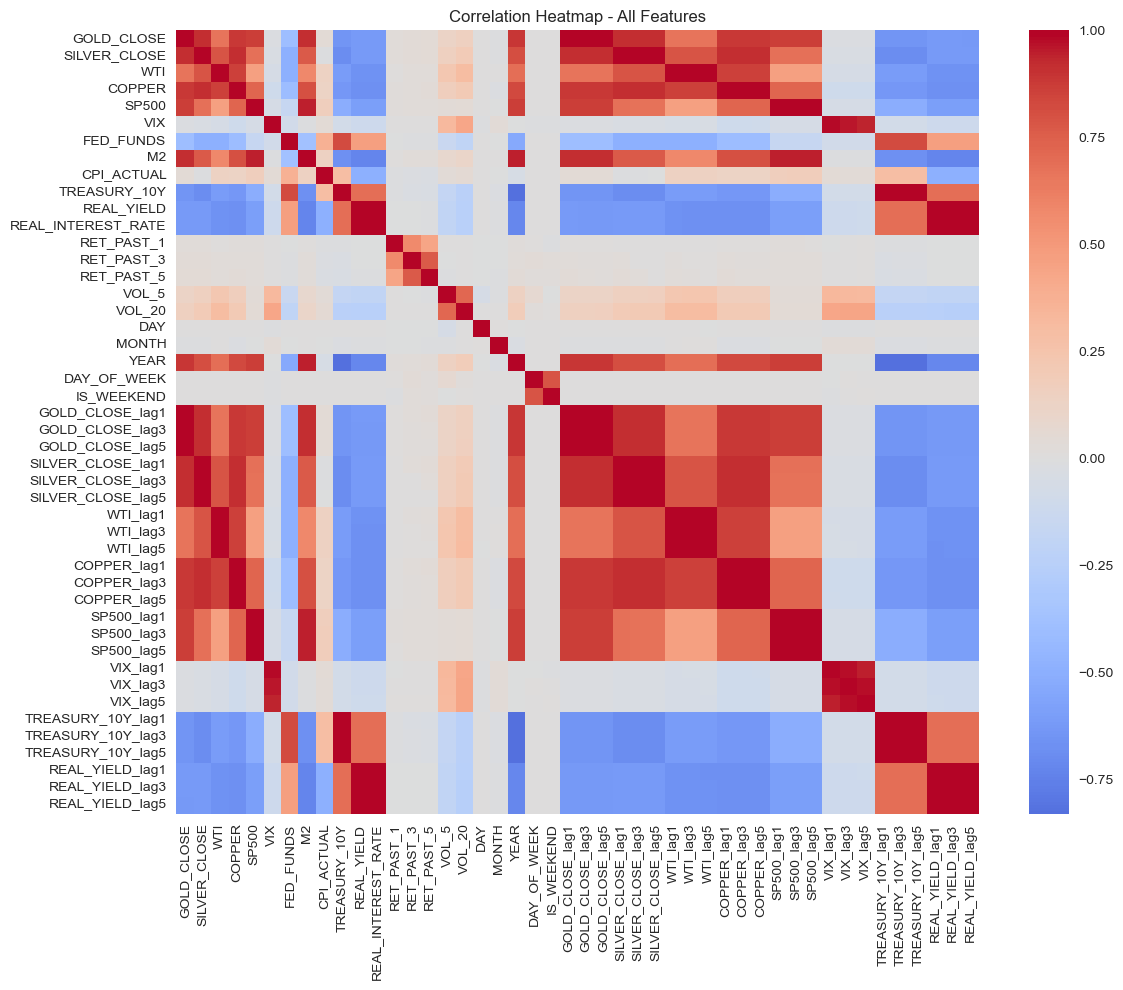

In [15]:
# Cell [7] - CORRELATION ANALYSIS

feature_cols_all = [c for c in df_ret.columns if c not in ["RET_1D", "TARGET_PRICE"]]

corr_matrix = df_ret[feature_cols_all].corr()

print("Ukuran correlation matrix:", corr_matrix.shape)

import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - All Features")
plt.tight_layout()
plt.show()


In [17]:
# Cell [8] - FEATURE SELECTION (BUANG HIGHLY CORRELATED FEATURES)

high_corr_pairs = []
threshold = 0.9

for i, col1 in enumerate(feature_cols_all):
    for col2 in feature_cols_all[i+1:]:
        corr_val = corr_matrix.loc[col1, col2]
        if abs(corr_val) > threshold:
            high_corr_pairs.append((col1, col2, corr_val))

print("Jumlah pasangan fitur dengan |corr| >", threshold, ":", len(high_corr_pairs))

to_drop = set()
for col1, col2, corr_val in high_corr_pairs:
    # buang kolom kedua secara konsisten
    if col2 not in to_drop:
        to_drop.add(col2)

print("\nFitur yang dibuang karena multikolinearitas (|corr|>0.9):")
print(sorted(to_drop))

df_fs = df_ret.drop(columns=list(to_drop))

print("\nShape sebelum FS:", df_ret.shape)
print("Shape sesudah FS:", df_fs.shape)

df_fs.head()


Jumlah pasangan fitur dengan |corr| > 0.9 : 93

Fitur yang dibuang karena multikolinearitas (|corr|>0.9):
['COPPER', 'COPPER_lag1', 'COPPER_lag3', 'COPPER_lag5', 'GOLD_CLOSE_lag1', 'GOLD_CLOSE_lag3', 'GOLD_CLOSE_lag5', 'M2', 'REAL_INTEREST_RATE', 'REAL_YIELD_lag1', 'REAL_YIELD_lag3', 'REAL_YIELD_lag5', 'SILVER_CLOSE', 'SILVER_CLOSE_lag1', 'SILVER_CLOSE_lag3', 'SILVER_CLOSE_lag5', 'SP500_lag1', 'SP500_lag3', 'SP500_lag5', 'TREASURY_10Y_lag1', 'TREASURY_10Y_lag3', 'TREASURY_10Y_lag5', 'VIX_lag1', 'VIX_lag3', 'VIX_lag5', 'WTI_lag1', 'WTI_lag3', 'WTI_lag5', 'YEAR']

Shape sebelum FS: (13001, 48)
Shape sesudah FS: (13001, 19)


,GOLD_CLOSE,WTI,SP500,VIX,FED_FUNDS,CPI_ACTUAL,TREASURY_10Y,REAL_YIELD,RET_PAST_1,RET_PAST_3,RET_PAST_5,VOL_5,VOL_20,RET_1D,TARGET_PRICE,DAY,MONTH,DAY_OF_WEEK,IS_WEEKEND
DATE,,,,,,,,,,,,,,,,,,,
1990-01-26,420.25,22.56,325.8,26.28,8.23,4.6,8.472,3.872,0.005094,0.017062,0.024625,0.006341,0.007349,0.000000,420.25,26,1,4,0
1990-01-27,420.25,22.56,325.8,26.28,8.23,4.6,8.472,3.872,0.000000,0.006225,0.028386,0.005220,0.007349,0.000000,420.25,27,1,5,1
1990-01-28,420.25,22.56,325.8,26.28,8.23,4.6,8.472,3.872,0.000000,0.005094,0.017062,0.004623,0.006788,-0.002974,419.00,28,1,6,1
1990-01-29,419.00,22.80,325.2,26.44,8.23,4.6,8.516,3.916,-0.002974,-0.002974,0.003232,0.002914,0.006683,-0.000358,418.85,29,1,0,0
1990-01-30,418.85,22.46,323.0,27.25,8.23,4.6,8.511,3.911,-0.000358,-0.003331,0.001746,0.002929,0.006017,-0.017071,411.70,30,1,1,0


In [19]:
# Cell [9] - DEFINE X & y UNTUK RET_1D

target_col_ret   = "RET_1D"
target_col_price = "TARGET_PRICE"

feature_cols_ret = [c for c in df_fs.columns if c not in [target_col_ret, target_col_price]]

X_all_ret   = df_fs[feature_cols_ret]
y_all_ret   = df_fs[target_col_ret]
y_all_price = df_fs[target_col_price]

print("Jumlah fitur:", len(feature_cols_ret))
print("X_all_ret:", X_all_ret.shape)
print("y_all_ret:", y_all_ret.shape)
print("y_all_price:", y_all_price.shape)


Jumlah fitur: 17
X_all_ret: (13001, 17)
y_all_ret: (13001,)
y_all_price: (13001,)


In [21]:
# Cell [10] - TIME-BASED SPLIT (70% train, 15% val, 15% test)

n = len(X_all_ret)
train_size = int(0.70 * n)
val_size   = int(0.15 * n)
test_size  = n - train_size - val_size

print("Total data :", n)
print("Train size:", train_size)
print("Val size  :", val_size)
print("Test size :", test_size)

X_train_ret = X_all_ret.iloc[:train_size]
X_val_ret   = X_all_ret.iloc[train_size:train_size + val_size]
X_test_ret  = X_all_ret.iloc[train_size + val_size:]

y_train_ret = y_all_ret.iloc[:train_size]
y_val_ret   = y_all_ret.iloc[train_size:train_size + val_size]
y_test_ret  = y_all_ret.iloc[train_size + val_size:]

y_train_price = y_all_price.iloc[:train_size]
y_val_price   = y_all_price.iloc[train_size:train_size + val_size]
y_test_price  = y_all_price.iloc[train_size + val_size:]

print("\nShapes:")
print("X_train_ret:", X_train_ret.shape)
print("X_val_ret  :", X_val_ret.shape)
print("X_test_ret :", X_test_ret.shape)


Total data : 13001
Train size: 9100
Val size  : 1950
Test size : 1951

Shapes:
X_train_ret: (9100, 17)
X_val_ret  : (1950, 17)
X_test_ret : (1951, 17)


In [23]:
# Cell [11] - ROBUST SCALER

scaler_ret = RobustScaler()

X_train_ret_scaled = scaler_ret.fit_transform(X_train_ret)
X_val_ret_scaled   = scaler_ret.transform(X_val_ret)
X_test_ret_scaled  = scaler_ret.transform(X_test_ret)

print("X_train_ret_scaled:", X_train_ret_scaled.shape)
print("X_val_ret_scaled  :", X_val_ret_scaled.shape)
print("X_test_ret_scaled :", X_test_ret_scaled.shape)


X_train_ret_scaled: (9100, 17)
X_val_ret_scaled  : (1950, 17)
X_test_ret_scaled : (1951, 17)


In [25]:
# Cell [12] - METRICS & HELPER

def evaluate_regression(y_true, y_pred, name="Model"):
    """
    MAPE di sini dalam bentuk PROPORSI (0.25 = 25%).
    Nanti kalau mau jadi %, tinggal dikali 100 di tabel.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true))  # proporsi, bukan persen

    print(f"=== {name} ===")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MAPE : {mape:.4f}")
    print()

    return {"model": name, "rmse": rmse, "mae": mae, "mape": mape}


def reconstruct_price_from_return(y_price_next, y_ret):
    """
    Dari definisi:
        y_ret = (P_{t+1} - P_t) / P_t
        y_price_next = P_{t+1}

    -> P_t = P_{t+1} / (1 + y_ret)
    """
    P_t = y_price_next / (1.0 + y_ret)
    return P_t

# hitung harga hari ini (P_t) untuk setiap baris train/val/test
P_train = reconstruct_price_from_return(y_train_price, y_train_ret)
P_val   = reconstruct_price_from_return(y_val_price,   y_val_ret)
P_test  = reconstruct_price_from_return(y_test_price,  y_test_ret)

P_train.head(), P_val.head(), P_test.head()


(DATE
 1990-01-26    420.25
 1990-01-27    420.25
 1990-01-28    420.25
 1990-01-29    419.00
 1990-01-30    418.85
 dtype: float64,
 DATE
 2014-12-26    1195.40
 2014-12-27    1195.40
 2014-12-28    1195.40
 2014-12-29    1183.10
 2014-12-30    1200.24
 dtype: float64,
 DATE
 2020-04-28    1708.63
 2020-04-29    1712.38
 2020-04-30    1685.05
 2020-05-01    1700.41
 2020-05-02    1700.41
 dtype: float64)

In [27]:
# Cell [13] - XGBOOST BASELINE (RET_1D)

xgb_base = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
)

xgb_base.fit(X_train_ret_scaled, y_train_ret)

# Validation
y_val_pred_ret_xgb_base = xgb_base.predict(X_val_ret_scaled)
y_val_pred_price_xgb_base = P_val.values * (1.0 + y_val_pred_ret_xgb_base)

metrics_xgb_base_val = evaluate_regression(
    y_val_price.values, y_val_pred_price_xgb_base,
    name="XGBoost (baseline, Val)"
)

# Test
y_test_pred_ret_xgb_base = xgb_base.predict(X_test_ret_scaled)
y_test_pred_price_xgb_base = P_test.values * (1.0 + y_test_pred_ret_xgb_base)

metrics_xgb_base_test = evaluate_regression(
    y_test_price.values, y_test_pred_price_xgb_base,
    name="XGBoost (baseline, Test)"
)


=== XGBoost (baseline, Val) ===
RMSE : 11.0638
MAE  : 7.7700
MAPE : 0.0059

=== XGBoost (baseline, Test) ===
RMSE : 22.9558
MAE  : 16.3684
MAPE : 0.0076



In [29]:
# Cell [14] - XGBOOST TUNED (RET_1D)

xgb_tuned = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    reg_lambda=5.0,
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
)

xgb_tuned.fit(X_train_ret_scaled, y_train_ret)

# Validation
y_val_pred_ret_xgb_tuned = xgb_tuned.predict(X_val_ret_scaled)
y_val_pred_price_xgb_tuned = P_val.values * (1.0 + y_val_pred_ret_xgb_tuned)

metrics_xgb_tuned_val = evaluate_regression(
    y_val_price.values, y_val_pred_price_xgb_tuned,
    name="XGBoost (tuned, Val)"
)

# Test
y_test_pred_ret_xgb_tuned = xgb_tuned.predict(X_test_ret_scaled)
y_test_pred_price_xgb_tuned = P_test.values * (1.0 + y_test_pred_ret_xgb_tuned)

metrics_xgb_tuned_test = evaluate_regression(
    y_test_price.values, y_test_pred_price_xgb_tuned,
    name="XGBoost (tuned, Test)"
)


=== XGBoost (tuned, Val) ===
RMSE : 11.5950
MAE  : 8.1446
MAPE : 0.0062

=== XGBoost (tuned, Test) ===
RMSE : 23.1474
MAE  : 17.3017
MAPE : 0.0081



In [31]:
# Cell [15] - RANDOM FOREST BASELINE

rf_base = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_base.fit(X_train_ret_scaled, y_train_ret)

# Val
y_val_pred_ret_rf_base = rf_base.predict(X_val_ret_scaled)
y_val_pred_price_rf_base = P_val.values * (1.0 + y_val_pred_ret_rf_base)

metrics_rf_base_val = evaluate_regression(
    y_val_price.values, y_val_pred_price_rf_base,
    name="Random Forest (baseline, Val)"
)

# Test
y_test_pred_ret_rf_base = rf_base.predict(X_test_ret_scaled)
y_test_pred_price_rf_base = P_test.values * (1.0 + y_test_pred_ret_rf_base)

metrics_rf_base_test = evaluate_regression(
    y_test_price.values, y_test_pred_price_rf_base,
    name="Random Forest (baseline, Test)"
)


=== Random Forest (baseline, Val) ===
RMSE : 9.8813
MAE  : 6.6402
MAPE : 0.0051

=== Random Forest (baseline, Test) ===
RMSE : 34.7440
MAE  : 29.6952
MAPE : 0.0142



In [33]:
# Cell [16] - RANDOM FOREST TUNED

rf_tuned = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_tuned.fit(X_train_ret_scaled, y_train_ret)

# Val
y_val_pred_ret_rf_tuned = rf_tuned.predict(X_val_ret_scaled)
y_val_pred_price_rf_tuned = P_val.values * (1.0 + y_val_pred_ret_rf_tuned)

metrics_rf_tuned_val = evaluate_regression(
    y_val_price.values, y_val_pred_price_rf_tuned,
    name="Random Forest (tuned, Val)"
)

# Test
y_test_pred_ret_rf_tuned = rf_tuned.predict(X_test_ret_scaled)
y_test_pred_price_rf_tuned = P_test.values * (1.0 + y_test_pred_ret_rf_tuned)

metrics_rf_tuned_test = evaluate_regression(
    y_test_price.values, y_test_pred_price_rf_tuned,
    name="Random Forest (tuned, Test)"
)


=== Random Forest (tuned, Val) ===
RMSE : 9.3913
MAE  : 5.8468
MAPE : 0.0045

=== Random Forest (tuned, Test) ===
RMSE : 33.5172
MAE  : 28.3671
MAPE : 0.0136



In [35]:
# Cell [17] - GRU SEQUENCE HELPER

def create_sequences(X_input, y_series, time_steps=10):
    X = np.asarray(X_input)
    y = np.asarray(y_series)

    X_seqs, y_seqs = [], []
    for i in range(time_steps, len(X)):
        X_seqs.append(X[i-time_steps:i, :])
        y_seqs.append(y[i])

    return np.array(X_seqs), np.array(y_seqs)

TIME_STEPS = 10
n_features = X_train_ret_scaled.shape[1]

# sequences dari data yang sudah discale
X_train_seq, y_train_seq = create_sequences(X_train_ret_scaled, y_train_ret, TIME_STEPS)
X_val_seq,   y_val_seq   = create_sequences(X_val_ret_scaled,   y_val_ret,   TIME_STEPS)
X_test_seq,  y_test_seq  = create_sequences(X_test_ret_scaled,  y_test_ret,  TIME_STEPS)

# harga besok & harga hari ini untuk setiap sequence
y_train_price_seq = y_train_price.iloc[TIME_STEPS:].values
y_val_price_seq   = y_val_price.iloc[TIME_STEPS:].values
y_test_price_seq  = y_test_price.iloc[TIME_STEPS:].values

P_train_seq = P_train.iloc[TIME_STEPS:].values
P_val_seq   = P_val.iloc[TIME_STEPS:].values
P_test_seq  = P_test.iloc[TIME_STEPS:].values

X_train_seq.shape, X_val_seq.shape, X_test_seq.shape


((9090, 10, 17), (1940, 10, 17), (1941, 10, 17))

In [37]:
# Cell [18] - GRU BASELINE

gru_base = Sequential([
    Input(shape=(TIME_STEPS, n_features)),
    GRU(64, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

gru_base.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_gru_base = gru_base.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Val
y_val_pred_ret_gru_base = gru_base.predict(X_val_seq).flatten()
y_val_pred_price_gru_base = P_val_seq * (1.0 + y_val_pred_ret_gru_base)

metrics_gru_base_val = evaluate_regression(
    y_val_price_seq, y_val_pred_price_gru_base,
    name="GRU (baseline, Val)"
)

# Test
y_test_pred_ret_gru_base = gru_base.predict(X_test_seq).flatten()
y_test_pred_price_gru_base = P_test_seq * (1.0 + y_test_pred_ret_gru_base)

metrics_gru_base_test = evaluate_regression(
    y_test_price_seq, y_test_pred_price_gru_base,
    name="GRU (baseline, Test)"
)


Epoch 1/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0093 - val_loss: 0.0016
Epoch 2/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 8.4879e-04 - val_loss: 3.6647e-04
Epoch 3/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.3045e-04 - val_loss: 9.9985e-05
Epoch 4/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0644e-04 - val_loss: 5.7491e-05
Epoch 5/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.5820e-05 - val_loss: 5.2924e-05
Epoch 6/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.0118e-05 - val_loss: 5.0905e-05
Epoch 7/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.7781e-05 - val_loss: 4.9420e-05
Epoch 8/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.7053e-05 - val_loss: 4.9008e-05
Epoch 9/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.5581e-05 - val_loss: 4.8718e-05
Epoch 10/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.4404e-05 - val_loss: 4.8842e-05
Epoch 11/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - l

In [39]:
# Cell [19] - GRU TUNED

gru_tuned = Sequential([
    Input(shape=(TIME_STEPS, n_features)),
    GRU(128, activation='tanh', return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1)
])

gru_tuned.compile(optimizer='adam', loss='mse')

early_stop_tuned = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_gru_tuned = gru_tuned.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_tuned],
    verbose=1
)

# Val
y_val_pred_ret_gru_tuned = gru_tuned.predict(X_val_seq).flatten()
y_val_pred_price_gru_tuned = P_val_seq * (1.0 + y_val_pred_ret_gru_tuned)

metrics_gru_tuned_val = evaluate_regression(
    y_val_price_seq, y_val_pred_price_gru_tuned,
    name="GRU (tuned, Val)"
)

# Test
y_test_pred_ret_gru_tuned = gru_tuned.predict(X_test_seq).flatten()
y_test_pred_price_gru_tuned = P_test_seq * (1.0 + y_test_pred_ret_gru_tuned)

metrics_gru_tuned_test = evaluate_regression(
    y_test_price_seq, y_test_pred_price_gru_tuned,
    name="GRU (tuned, Test)"
)


Epoch 1/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0085 - val_loss: 0.0010
Epoch 2/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0012 - val_loss: 3.8453e-04
Epoch 3/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4.1592e-04 - val_loss: 1.5020e-04
Epoch 4/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.7896e-04 - val_loss: 1.0417e-04
Epoch 5/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.0612e-04 - val_loss: 7.3505e-05
Epoch 6/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 8.9303e-05 - val_loss: 6.1570e-05
Epoch 7/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 8.0836e-05 - val_loss: 5.3697e-05
Epoch 8/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.9865e-05 - val_loss: 5.0039e-05
Epoch 9/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 7.8197e-05 - val_loss: 4.9585e-05
Epoch 10/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 7.6799e-05 - val_loss: 4.9500e-05
Epoch 11/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss:

In [41]:
# Cell [20] - EVALUATION TABLES (BASELINE & TUNED)

baseline_rows = [
    {
        "Model": "XGBoost (baseline)",
        "Val_RMSE": metrics_xgb_base_val["rmse"],
        "Val_MAE":  metrics_xgb_base_val["mae"],
        "Val_MAPE": metrics_xgb_base_val["mape"],
        "Test_RMSE": metrics_xgb_base_test["rmse"],
        "Test_MAE":  metrics_xgb_base_test["mae"],
        "Test_MAPE": metrics_xgb_base_test["mape"],
    },
    {
        "Model": "Random Forest (baseline)",
        "Val_RMSE": metrics_rf_base_val["rmse"],
        "Val_MAE":  metrics_rf_base_val["mae"],
        "Val_MAPE": metrics_rf_base_val["mape"],
        "Test_RMSE": metrics_rf_base_test["rmse"],
        "Test_MAE":  metrics_rf_base_test["mae"],
        "Test_MAPE": metrics_rf_base_test["mape"],
    },
    {
        "Model": "GRU (baseline)",
        "Val_RMSE": metrics_gru_base_val["rmse"],
        "Val_MAE":  metrics_gru_base_val["mae"],
        "Val_MAPE": metrics_gru_base_val["mape"],
        "Test_RMSE": metrics_gru_base_test["rmse"],
        "Test_MAE":  metrics_gru_base_test["mae"],
        "Test_MAPE": metrics_gru_base_test["mape"],
    },
]

tuned_rows = [
    {
        "Model": "XGBoost (tuned)",
        "Val_RMSE": metrics_xgb_tuned_val["rmse"],
        "Val_MAE":  metrics_xgb_tuned_val["mae"],
        "Val_MAPE": metrics_xgb_tuned_val["mape"],
        "Test_RMSE": metrics_xgb_tuned_test["rmse"],
        "Test_MAE":  metrics_xgb_tuned_test["mae"],
        "Test_MAPE": metrics_xgb_tuned_test["mape"],
    },
    {
        "Model": "Random Forest (tuned)",
        "Val_RMSE": metrics_rf_tuned_val["rmse"],
        "Val_MAE":  metrics_rf_tuned_val["mae"],
        "Val_MAPE": metrics_rf_tuned_val["mape"],
        "Test_RMSE": metrics_rf_tuned_test["rmse"],
        "Test_MAE":  metrics_rf_tuned_test["mae"],
        "Test_MAPE": metrics_rf_tuned_test["mape"],
    },
    {
        "Model": "GRU (tuned)",
        "Val_RMSE": metrics_gru_tuned_val["rmse"],
        "Val_MAE":  metrics_gru_tuned_val["mae"],
        "Val_MAPE": metrics_gru_tuned_val["mape"],
        "Test_RMSE": metrics_gru_tuned_test["rmse"],
        "Test_MAE":  metrics_gru_tuned_test["mae"],
        "Test_MAPE": metrics_gru_tuned_test["mape"],
    },
]

baseline_df = pd.DataFrame(baseline_rows)
tuned_df    = pd.DataFrame(tuned_rows)

print("=== BASELINE EVALUATION TABLE ===")
display(baseline_df)

print("\n=== TUNED EVALUATION TABLE ===")
display(tuned_df)


=== BASELINE EVALUATION TABLE ===


,Model,Val_RMSE,Val_MAE,Val_MAPE,Test_RMSE,Test_MAE,Test_MAPE
0,XGBoost (baseline),11.063809,7.769975,0.005914,22.955758,16.368429,0.007625
1,Random Forest (baseline),9.881251,6.640207,0.005122,34.744037,29.695162,0.014248
2,GRU (baseline),9.269470,5.852570,0.004510,27.007567,16.109102,0.007849



=== TUNED EVALUATION TABLE ===


,Model,Val_RMSE,Val_MAE,Val_MAPE,Test_RMSE,Test_MAE,Test_MAPE
0,XGBoost (tuned),11.594955,8.144603,0.006158,23.147438,17.301653,0.008062
1,Random Forest (tuned),9.391301,5.846800,0.004507,33.517169,28.367099,0.013633
2,GRU (tuned),9.266012,5.894448,0.004549,18.214592,11.589836,0.005401


In [43]:
# Cell [L1] - LSTM BASELINE (RET_1D)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# pastikan TIME_STEPS dan n_features sudah didefinisikan seperti di GRU
print("TIME_STEPS:", TIME_STEPS, "| n_features:", n_features)

lstm_base = Sequential([
    Input(shape=(TIME_STEPS, n_features)),
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_base.compile(optimizer='adam', loss='mse')

early_stop_lstm_base = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_lstm_base = lstm_base.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_lstm_base],
    verbose=1
)

# === Validation ===
y_val_pred_ret_lstm_base = lstm_base.predict(X_val_seq).flatten()
y_val_pred_price_lstm_base = P_val_seq * (1.0 + y_val_pred_ret_lstm_base)

metrics_lstm_base_val = evaluate_regression(
    y_val_price_seq,
    y_val_pred_price_lstm_base,
    name="LSTM (baseline, Val)"
)

# === Test ===
y_test_pred_ret_lstm_base = lstm_base.predict(X_test_seq).flatten()
y_test_pred_price_lstm_base = P_test_seq * (1.0 + y_test_pred_ret_lstm_base)

metrics_lstm_base_test = evaluate_regression(
    y_test_price_seq,
    y_test_pred_price_lstm_base,
    name="LSTM (baseline, Test)"
)


TIME_STEPS: 10 | n_features: 17
Epoch 1/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0026 - val_loss: 3.7528e-04
Epoch 2/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.3807e-04 - val_loss: 1.4794e-04
Epoch 3/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.6269e-04 - val_loss: 1.1205e-04
Epoch 4/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1038e-04 - val_loss: 7.9480e-05
Epoch 5/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.5322e-05 - val_loss: 6.5267e-05
Epoch 6/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.7285e-05 - val_loss: 6.0561e-05
Epoch 7/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.5917e-05 - val_loss: 5.8111e-05
Epoch 8/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.5693e-05 - val_loss: 5.8327e-05
Epoch 9/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.5830e-05 - val_loss: 5.4367e-05
Epoch 10/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.4592e-05 - val_loss: 5.3580e-05
Epoch 11/100
285/285 

In [45]:
# Cell [L2] - LSTM TUNED (RET_1D)

lstm_tuned = Sequential([
    Input(shape=(TIME_STEPS, n_features)),
    LSTM(128, activation='tanh', return_sequences=True),
    Dropout(0.3),
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1)
])

lstm_tuned.compile(optimizer='adam', loss='mse')

early_stop_lstm_tuned = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

history_lstm_tuned = lstm_tuned.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=120,
    batch_size=32,
    callbacks=[early_stop_lstm_tuned],
    verbose=1
)

# === Validation ===
y_val_pred_ret_lstm_tuned = lstm_tuned.predict(X_val_seq).flatten()
y_val_pred_price_lstm_tuned = P_val_seq * (1.0 + y_val_pred_ret_lstm_tuned)

metrics_lstm_tuned_val = evaluate_regression(
    y_val_price_seq,
    y_val_pred_price_lstm_tuned,
    name="LSTM (tuned, Val)"
)

# === Test ===
y_test_pred_ret_lstm_tuned = lstm_tuned.predict(X_test_seq).flatten()
y_test_pred_price_lstm_tuned = P_test_seq * (1.0 + y_test_pred_ret_lstm_tuned)

metrics_lstm_tuned_test = evaluate_regression(
    y_test_price_seq,
    y_test_pred_price_lstm_tuned,
    name="LSTM (tuned, Test)"
)


Epoch 1/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 7.3048e-04 - val_loss: 1.3132e-04
Epoch 2/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 1.3205e-04 - val_loss: 9.5575e-05
Epoch 3/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 9.6850e-05 - val_loss: 7.5664e-05
Epoch 4/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 8.6342e-05 - val_loss: 5.6126e-05
Epoch 5/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 8.0342e-05 - val_loss: 5.3203e-05
Epoch 6/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 7.8504e-05 - val_loss: 5.0489e-05
Epoch 7/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 7.7161e-05 - val_loss: 5.0656e-05
Epoch 8/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7.7131e-05 - val_loss: 4.9530e-05
Epoch 9/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 7.6779e-05 - val_loss: 4.8916e-05
Epoch 10/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 7.7171e-05 - val_loss: 5.0408e-05
Epoch 11/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 

In [47]:
# Cell [C1] - CNN BASELINE (RET_1D)

from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

cnn_base = Sequential([
    Input(shape=(TIME_STEPS, n_features)),
    Conv1D(filters=32, kernel_size=3, padding='causal', activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])

cnn_base.compile(optimizer='adam', loss='mse')

early_stop_cnn_base = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_cnn_base = cnn_base.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_cnn_base],
    verbose=1
)

# === Validation ===
y_val_pred_ret_cnn_base = cnn_base.predict(X_val_seq).flatten()
y_val_pred_price_cnn_base = P_val_seq * (1.0 + y_val_pred_ret_cnn_base)

metrics_cnn_base_val = evaluate_regression(
    y_val_price_seq,
    y_val_pred_price_cnn_base,
    name="CNN (baseline, Val)"
)

# === Test ===
y_test_pred_ret_cnn_base = cnn_base.predict(X_test_seq).flatten()
y_test_pred_price_cnn_base = P_test_seq * (1.0 + y_test_pred_ret_cnn_base)

metrics_cnn_base_test = evaluate_regression(
    y_test_price_seq,
    y_test_pred_price_cnn_base,
    name="CNN (baseline, Test)"
)


Epoch 1/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0239 - val_loss: 0.0097
Epoch 2/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0047 - val_loss: 0.0047
Epoch 3/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0022 - val_loss: 0.0034
Epoch 4/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0012 - val_loss: 0.0023
Epoch 5/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.1717e-04 - val_loss: 0.0015
Epoch 6/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.3716e-04 - val_loss: 0.0010
Epoch 7/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.7994e-04 - val_loss: 5.4890e-04
Epoch 8/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.8887e-04 - val_loss: 3.3688e-04
Epoch 9/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.4385e-04 - val_loss: 2.3748e-04
Epoch 10/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2033e-04 - val_loss: 2.2634e-04
Epoch 11/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1219e-04 - val_loss: 2.05

In [49]:
# Cell [C2] - CNN TUNED (RET_1D)

from tensorflow.keras.layers import GlobalAveragePooling1D

cnn_tuned = Sequential([
    Input(shape=(TIME_STEPS, n_features)),
    Conv1D(filters=64, kernel_size=3, padding='causal', activation='relu'),
    Conv1D(filters=64, kernel_size=3, padding='causal', activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dense(1)
])

cnn_tuned.compile(optimizer='adam', loss='mse')

early_stop_cnn_tuned = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

history_cnn_tuned = cnn_tuned.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=120,
    batch_size=32,
    callbacks=[early_stop_cnn_tuned],
    verbose=1
)

# === Validation ===
y_val_pred_ret_cnn_tuned = cnn_tuned.predict(X_val_seq).flatten()
y_val_pred_price_cnn_tuned = P_val_seq * (1.0 + y_val_pred_ret_cnn_tuned)

metrics_cnn_tuned_val = evaluate_regression(
    y_val_price_seq,
    y_val_pred_price_cnn_tuned,
    name="CNN (tuned, Val)"
)

# === Test ===
y_test_pred_ret_cnn_tuned = cnn_tuned.predict(X_test_seq).flatten()
y_test_pred_price_cnn_tuned = P_test_seq * (1.0 + y_test_pred_ret_cnn_tuned)

metrics_cnn_tuned_test = evaluate_regression(
    y_test_price_seq,
    y_test_pred_price_cnn_tuned,
    name="CNN (tuned, Test)"
)


Epoch 1/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0035 - val_loss: 1.9476e-04
Epoch 2/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.5425e-04 - val_loss: 1.6684e-04
Epoch 3/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.6044e-04 - val_loss: 7.9506e-05
Epoch 4/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.2657e-04 - val_loss: 7.0584e-05
Epoch 5/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0707e-04 - val_loss: 6.1617e-05
Epoch 6/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.4093e-05 - val_loss: 5.6668e-05
Epoch 7/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.6853e-05 - val_loss: 5.1744e-05
Epoch 8/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.4046e-05 - val_loss: 5.2295e-05
Epoch 9/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.3016e-05 - val_loss: 5.4455e-05
Epoch 10/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.2951e-05 - val_loss: 5.1800e-05
Epoch 11/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [51]:
# Cell [EVAL] - EVALUATION TABLE (XGB, RF, GRU, LSTM, CNN)

import pandas as pd

baseline_rows = [
    {
        "Model": "XGBoost (baseline)",
        "Val_RMSE": metrics_xgb_base_val["rmse"],
        "Val_MAE":  metrics_xgb_base_val["mae"],
        "Val_MAPE": metrics_xgb_base_val["mape"],
        "Test_RMSE": metrics_xgb_base_test["rmse"],
        "Test_MAE":  metrics_xgb_base_test["mae"],
        "Test_MAPE": metrics_xgb_base_test["mape"],
    },
    {
        "Model": "Random Forest (baseline)",
        "Val_RMSE": metrics_rf_base_val["rmse"],
        "Val_MAE":  metrics_rf_base_val["mae"],
        "Val_MAPE": metrics_rf_base_val["mape"],
        "Test_RMSE": metrics_rf_base_test["rmse"],
        "Test_MAE":  metrics_rf_base_test["mae"],
        "Test_MAPE": metrics_rf_base_test["mape"],
    },
    {
        "Model": "GRU (baseline)",
        "Val_RMSE": metrics_gru_base_val["rmse"],
        "Val_MAE":  metrics_gru_base_val["mae"],
        "Val_MAPE": metrics_gru_base_val["mape"],
        "Test_RMSE": metrics_gru_base_test["rmse"],
        "Test_MAE":  metrics_gru_base_test["mae"],
        "Test_MAPE": metrics_gru_base_test["mape"],
    },
    {
        "Model": "LSTM (baseline)",
        "Val_RMSE": metrics_lstm_base_val["rmse"],
        "Val_MAE":  metrics_lstm_base_val["mae"],
        "Val_MAPE": metrics_lstm_base_val["mape"],
        "Test_RMSE": metrics_lstm_base_test["rmse"],
        "Test_MAE":  metrics_lstm_base_test["mae"],
        "Test_MAPE": metrics_lstm_base_test["mape"],
    },
    {
        "Model": "CNN (baseline)",
        "Val_RMSE": metrics_cnn_base_val["rmse"],
        "Val_MAE":  metrics_cnn_base_val["mae"],
        "Val_MAPE": metrics_cnn_base_val["mape"],
        "Test_RMSE": metrics_cnn_base_test["rmse"],
        "Test_MAE":  metrics_cnn_base_test["mae"],
        "Test_MAPE": metrics_cnn_base_test["mape"],
    },
]

tuned_rows = [
    {
        "Model": "XGBoost (tuned)",
        "Val_RMSE": metrics_xgb_tuned_val["rmse"],
        "Val_MAE":  metrics_xgb_tuned_val["mae"],
        "Val_MAPE": metrics_xgb_tuned_val["mape"],
        "Test_RMSE": metrics_xgb_tuned_test["rmse"],
        "Test_MAE":  metrics_xgb_tuned_test["mae"],
        "Test_MAPE": metrics_xgb_tuned_test["mape"],
    },
    {
        "Model": "Random Forest (tuned)",
        "Val_RMSE": metrics_rf_tuned_val["rmse"],
        "Val_MAE":  metrics_rf_tuned_val["mae"],
        "Val_MAPE": metrics_rf_tuned_val["mape"],
        "Test_RMSE": metrics_rf_tuned_test["rmse"],
        "Test_MAE":  metrics_rf_tuned_test["mae"],
        "Test_MAPE": metrics_rf_tuned_test["mape"],
    },
    {
        "Model": "GRU (tuned)",
        "Val_RMSE": metrics_gru_tuned_val["rmse"],
        "Val_MAE":  metrics_gru_tuned_val["mae"],
        "Val_MAPE": metrics_gru_tuned_val["mape"],
        "Test_RMSE": metrics_gru_tuned_test["rmse"],
        "Test_MAE":  metrics_gru_tuned_test["mae"],
        "Test_MAPE": metrics_gru_tuned_test["mape"],
    },
    {
        "Model": "LSTM (tuned)",
        "Val_RMSE": metrics_lstm_tuned_val["rmse"],
        "Val_MAE":  metrics_lstm_tuned_val["mae"],
        "Val_MAPE": metrics_lstm_tuned_val["mape"],
        "Test_RMSE": metrics_lstm_tuned_test["rmse"],
        "Test_MAE":  metrics_lstm_tuned_test["mae"],
        "Test_MAPE": metrics_lstm_tuned_test["mape"],
    },
    {
        "Model": "CNN (tuned)",
        "Val_RMSE": metrics_cnn_tuned_val["rmse"],
        "Val_MAE":  metrics_cnn_tuned_val["mae"],
        "Val_MAPE": metrics_cnn_tuned_val["mape"],
        "Test_RMSE": metrics_cnn_tuned_test["rmse"],
        "Test_MAE":  metrics_cnn_tuned_test["mae"],
        "Test_MAPE": metrics_cnn_tuned_test["mape"],
    },
]

baseline_df = pd.DataFrame(baseline_rows)
tuned_df    = pd.DataFrame(tuned_rows)

print("=== BASELINE EVALUATION TABLE ===")
display(baseline_df)

print("\n=== TUNED EVALUATION TABLE ===")
display(tuned_df)


=== BASELINE EVALUATION TABLE ===


,Model,Val_RMSE,Val_MAE,Val_MAPE,Test_RMSE,Test_MAE,Test_MAPE
0,XGBoost (baseline),11.063809,7.769975,0.005914,22.955758,16.368429,0.007625
1,Random Forest (baseline),9.881251,6.640207,0.005122,34.744037,29.695162,0.014248
2,GRU (baseline),9.269470,5.852570,0.004510,27.007567,16.109102,0.007849
3,LSTM (baseline),9.267489,5.896432,0.004551,23.501969,14.189763,0.006244
4,CNN (baseline),14.867749,9.468042,0.007244,46.717692,31.067483,0.014085



=== TUNED EVALUATION TABLE ===


,Model,Val_RMSE,Val_MAE,Val_MAPE,Test_RMSE,Test_MAE,Test_MAPE
0,XGBoost (tuned),11.594955,8.144603,0.006158,23.147438,17.301653,0.008062
1,Random Forest (tuned),9.391301,5.846800,0.004507,33.517169,28.367099,0.013633
2,GRU (tuned),9.266012,5.894448,0.004549,18.214592,11.589836,0.005401
3,LSTM (tuned),9.219759,5.637330,0.004346,20.663068,14.348616,0.006514
4,CNN (tuned),9.298853,5.913422,0.004563,18.620083,12.061127,0.005595


In [53]:
import matplotlib.pyplot as plt

def plot_model_val_test(
    y_val_true,
    y_val_pred,
    y_test_true,
    y_test_pred,
    model_name="XGBoost",
    version_name="Baseline",      # "Baseline" atau "Tuned"
    pred_label="Predicted",
    save_path=None                # isi string path kalau mau disimpan
):
    """
    Bikin figure 2 kolom:
      kiri  : Actual vs Predicted (Validation set)
      kanan : Actual vs Predicted (Test set)
    """
    # --- Sinkronisasi panjang VAL ---
    L_val = min(len(y_val_true), len(y_val_pred))
    val_dates = y_val_true.index[-L_val:]
    val_actual = y_val_true.values[-L_val:]
    val_pred   = y_val_pred[-L_val:]

    # --- Sinkronisasi panjang TEST ---
    L_test = min(len(y_test_true), len(y_test_pred))
    test_dates = y_test_true.index[-L_test:]
    test_actual = y_test_true.values[-L_test:]
    test_pred   = y_test_pred[-L_test:]

    # --- Plot ---
    plt.figure(figsize=(12, 4))

    # Validation (subplot kiri)
    plt.subplot(1, 2, 1)
    plt.plot(val_dates, val_actual, color="black", linewidth=2, label="Actual")
    plt.plot(val_dates, val_pred,   color="orange", alpha=0.9, label=pred_label)
    plt.title(f"{model_name} {version_name} – Validation Set", fontsize=11)
    plt.xlabel("Date")
    plt.ylabel("Gold Price")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper left")

    # Test (subplot kanan)
    plt.subplot(1, 2, 2)
    plt.plot(test_dates, test_actual, color="black", linewidth=2, label="Actual")
    plt.plot(test_dates, test_pred,   color="orange", alpha=0.9, label=pred_label)
    plt.title(f"{model_name} {version_name} – Test Set", fontsize=11)
    plt.xlabel("Date")
    plt.ylabel("Gold Price")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper left")

    plt.suptitle(f"{model_name} {version_name} – Actual vs Predicted", fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path is not None:
        plt.savefig(save_path, dpi=300)
    plt.show()


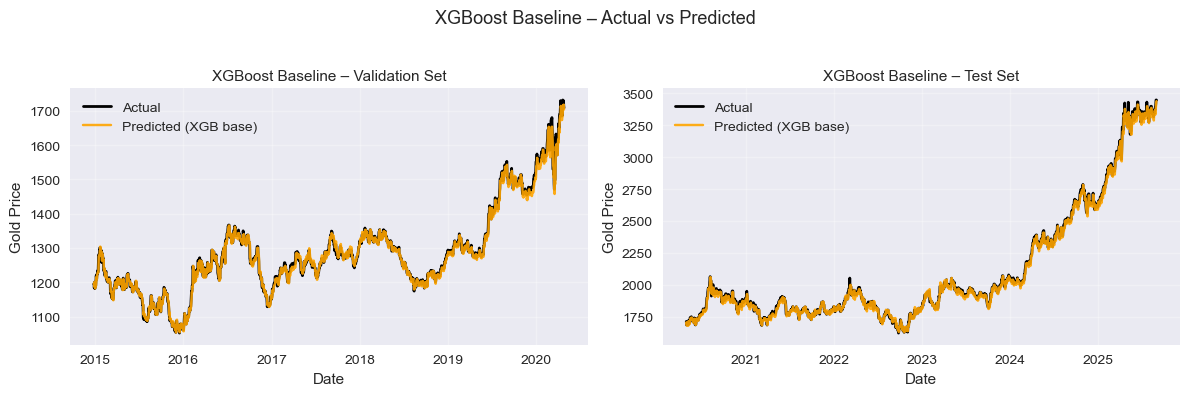

In [55]:
# XGBoost Baseline – untuk slide "EVALUASI AWAL XGBOOST"
plot_model_val_test(
    y_val_true   = y_val_price,
    y_val_pred   = y_val_pred_price_xgb_base,
    y_test_true  = y_test_price,
    y_test_pred  = y_test_pred_price_xgb_base,
    model_name   = "XGBoost",
    version_name = "Baseline",
    pred_label   = "Predicted (XGB base)",
    save_path    = "xgb_baseline_val_test.png"   # atau None kalau cuma mau lihat
)


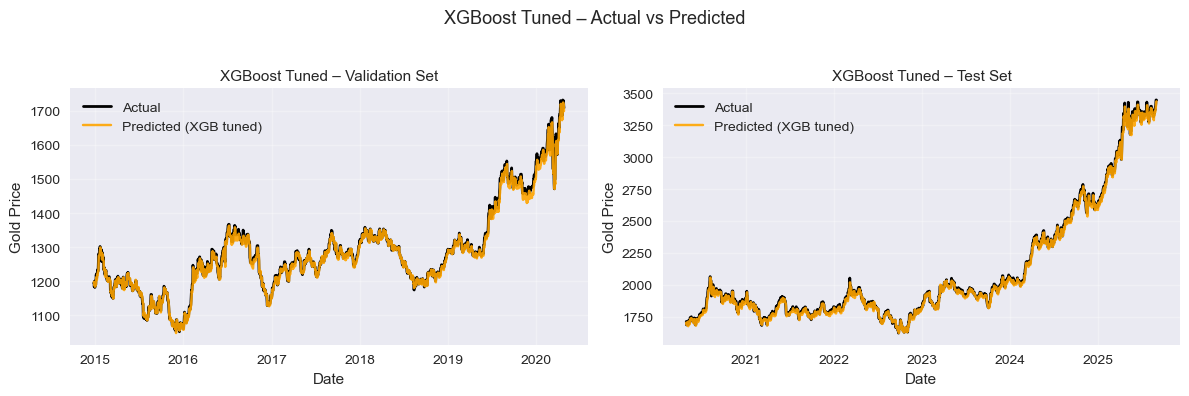

In [57]:
# XGBoost Tuned – untuk slide "XGBOOST SETELAH TUNING"
plot_model_val_test(
    y_val_true   = y_val_price,
    y_val_pred   = y_val_pred_price_xgb_tuned,
    y_test_true  = y_test_price,
    y_test_pred  = y_test_pred_price_xgb_tuned,
    model_name   = "XGBoost",
    version_name = "Tuned",
    pred_label   = "Predicted (XGB tuned)",
    save_path    = "xgb_tuned_val_test.png"
)


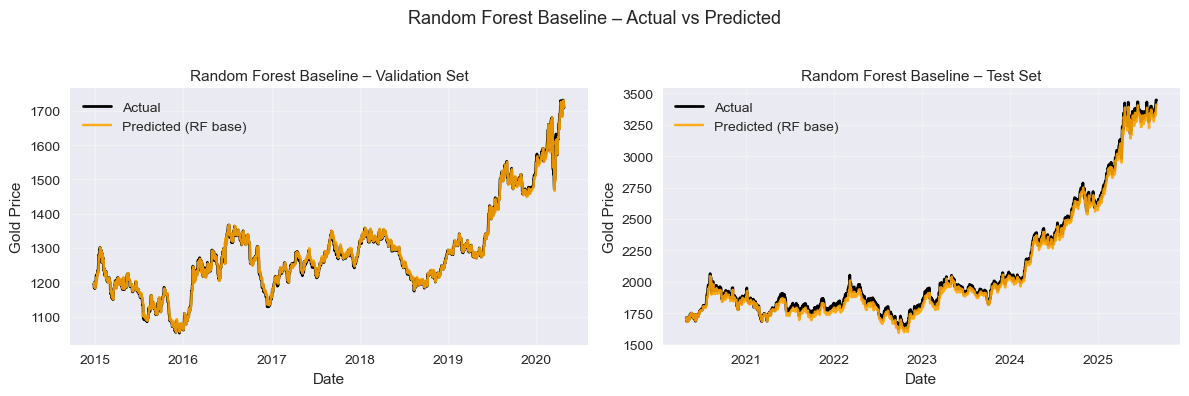

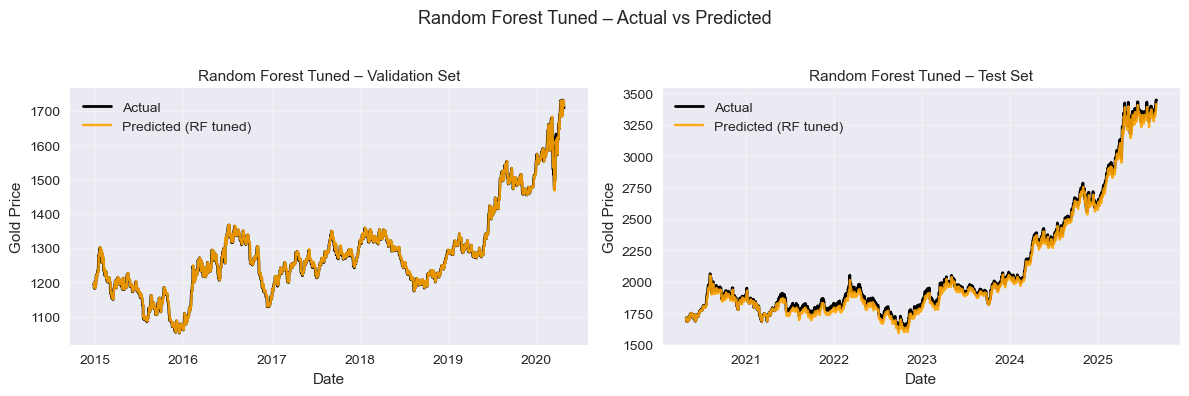

In [59]:
plot_model_val_test(
    y_val_price, y_val_pred_price_rf_base,
    y_test_price, y_test_pred_price_rf_base,
    model_name="Random Forest",
    version_name="Baseline",
    pred_label="Predicted (RF base)",
    save_path="rf_baseline_val_test.png"
)

plot_model_val_test(
    y_val_price, y_val_pred_price_rf_tuned,
    y_test_price, y_test_pred_price_rf_tuned,
    model_name="Random Forest",
    version_name="Tuned",
    pred_label="Predicted (RF tuned)",
    save_path="rf_tuned_val_test.png"
)


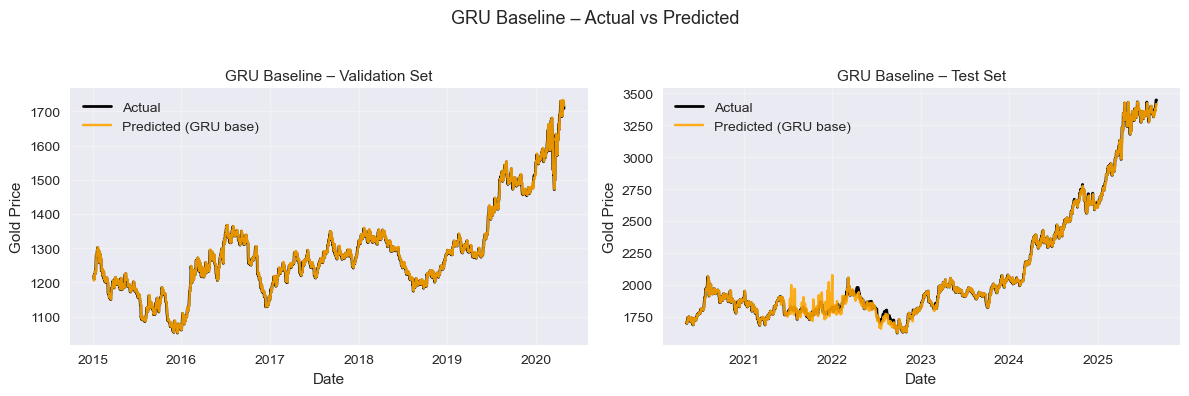

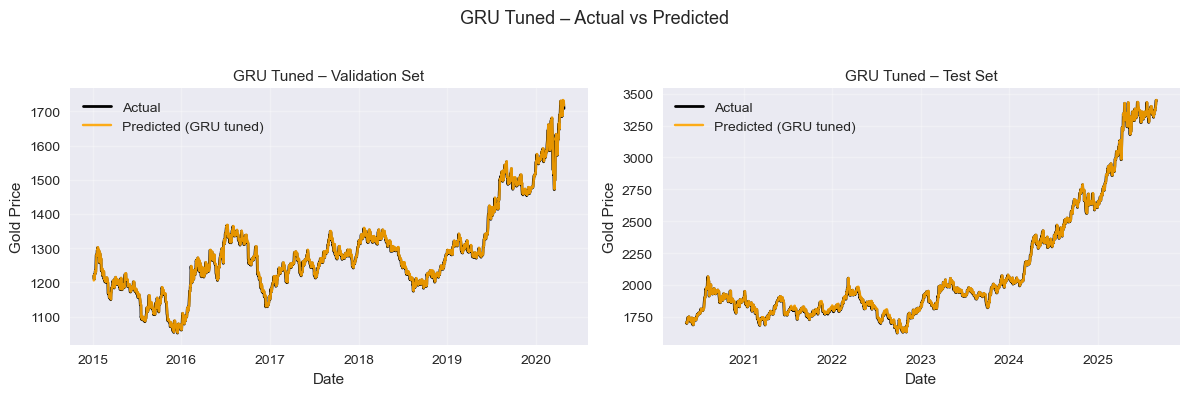

In [61]:
plot_model_val_test(
    y_val_price, y_val_pred_price_gru_base,
    y_test_price, y_test_pred_price_gru_base,
    model_name="GRU",
    version_name="Baseline",
    pred_label="Predicted (GRU base)",
    save_path="gru_baseline_val_test.png"
)

plot_model_val_test(
    y_val_price, y_val_pred_price_gru_tuned,
    y_test_price, y_test_pred_price_gru_tuned,
    model_name="GRU",
    version_name="Tuned",
    pred_label="Predicted (GRU tuned)",
    save_path="gru_tuned_val_test.png"
)


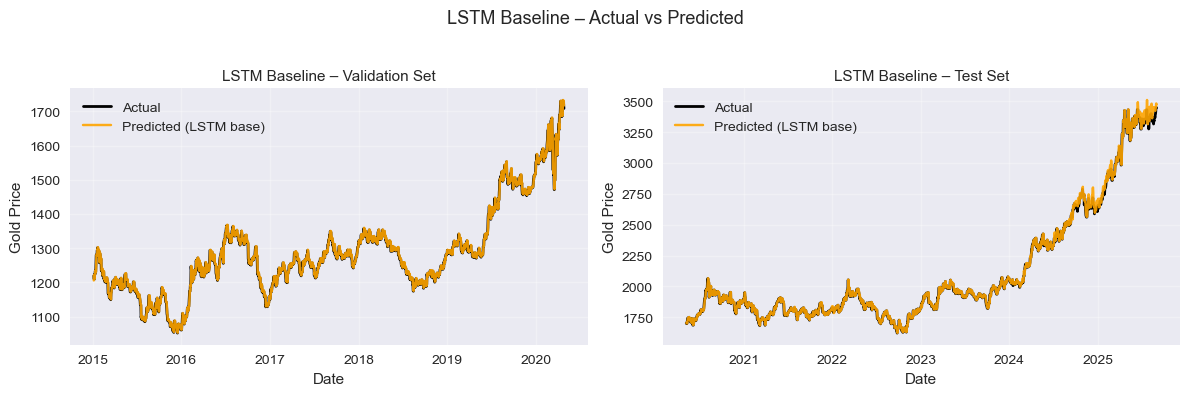

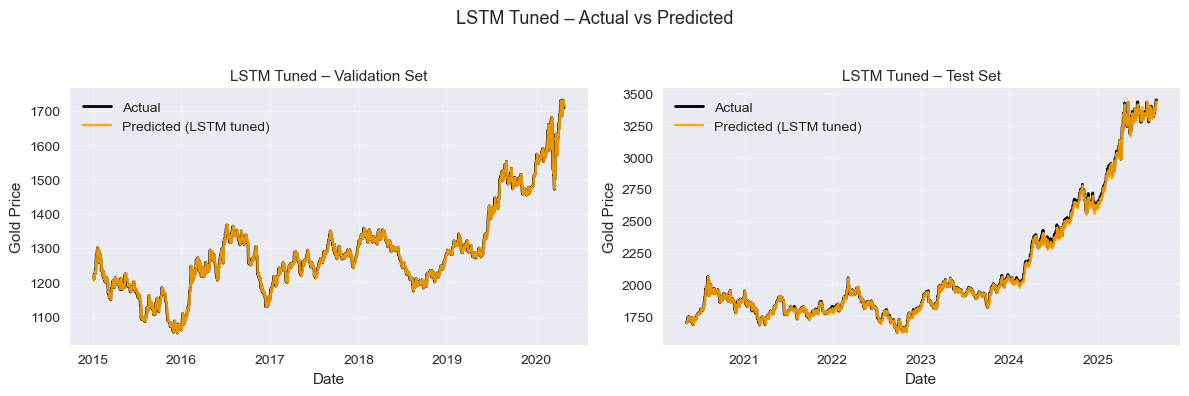

In [63]:
plot_model_val_test(
    y_val_price, y_val_pred_price_lstm_base,
    y_test_price, y_test_pred_price_lstm_base,
    model_name="LSTM",
    version_name="Baseline",
    pred_label="Predicted (LSTM base)",
    save_path="lstm_baseline_val_test.png"
)

plot_model_val_test(
    y_val_price, y_val_pred_price_lstm_tuned,
    y_test_price, y_test_pred_price_lstm_tuned,
    model_name="LSTM",
    version_name="Tuned",
    pred_label="Predicted (LSTM tuned)",
    save_path="lstm_tuned_val_test.png"
)


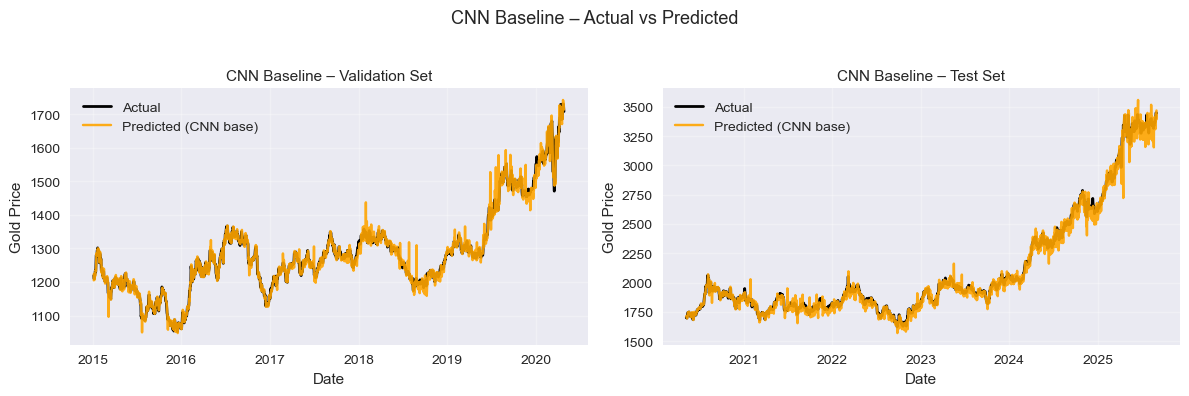

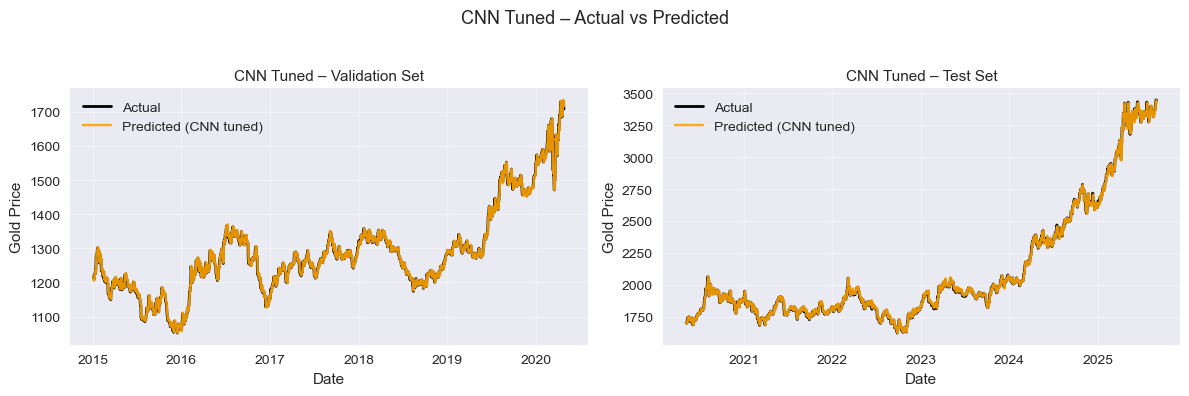

In [65]:
plot_model_val_test(
    y_val_price, y_val_pred_price_cnn_base,
    y_test_price, y_test_pred_price_cnn_base,
    model_name="CNN",
    version_name="Baseline",
    pred_label="Predicted (CNN base)",
    save_path="cnn_baseline_val_test.png"
)

plot_model_val_test(
    y_val_price, y_val_pred_price_cnn_tuned,
    y_test_price, y_test_pred_price_cnn_tuned,
    model_name="CNN",
    version_name="Tuned",
    pred_label="Predicted (CNN tuned)",
    save_path="cnn_tuned_val_test.png"
)


In [67]:
# === BASELINE TEST-SET TABLE ONLY ===

import pandas as pd

baseline_test_rows = [
    {
        "Model": "XGBoost (baseline)",
        "Test_RMSE": metrics_xgb_base_test["rmse"],
        "Test_MAE":  metrics_xgb_base_test["mae"],
        "Test_MAPE": metrics_xgb_base_test["mape"],
    },
    {
        "Model": "Random Forest (baseline)",
        "Test_RMSE": metrics_rf_base_test["rmse"],
        "Test_MAE":  metrics_rf_base_test["mae"],
        "Test_MAPE": metrics_rf_base_test["mape"],
    },
    {
        "Model": "GRU (baseline)",
        "Test_RMSE": metrics_gru_base_test["rmse"],
        "Test_MAE":  metrics_gru_base_test["mae"],
        "Test_MAPE": metrics_gru_base_test["mape"],
    },
    {
        "Model": "LSTM (baseline)",
        "Test_RMSE": metrics_lstm_base_test["rmse"],
        "Test_MAE":  metrics_lstm_base_test["mae"],
        "Test_MAPE": metrics_lstm_base_test["mape"],
    },
    {
        "Model": "CNN (baseline)",
        "Test_RMSE": metrics_cnn_base_test["rmse"],
        "Test_MAE":  metrics_cnn_base_test["mae"],
        "Test_MAPE": metrics_cnn_base_test["mape"],
    },
]

baseline_test_df = pd.DataFrame(baseline_test_rows)

print("=== BASELINE TEST-SET TABLE ===")
display(baseline_test_df)


=== BASELINE TEST-SET TABLE ===


,Model,Test_RMSE,Test_MAE,Test_MAPE
0,XGBoost (baseline),22.955758,16.368429,0.007625
1,Random Forest (baseline),34.744037,29.695162,0.014248
2,GRU (baseline),27.007567,16.109102,0.007849
3,LSTM (baseline),23.501969,14.189763,0.006244
4,CNN (baseline),46.717692,31.067483,0.014085


Length used for plotting: 1941


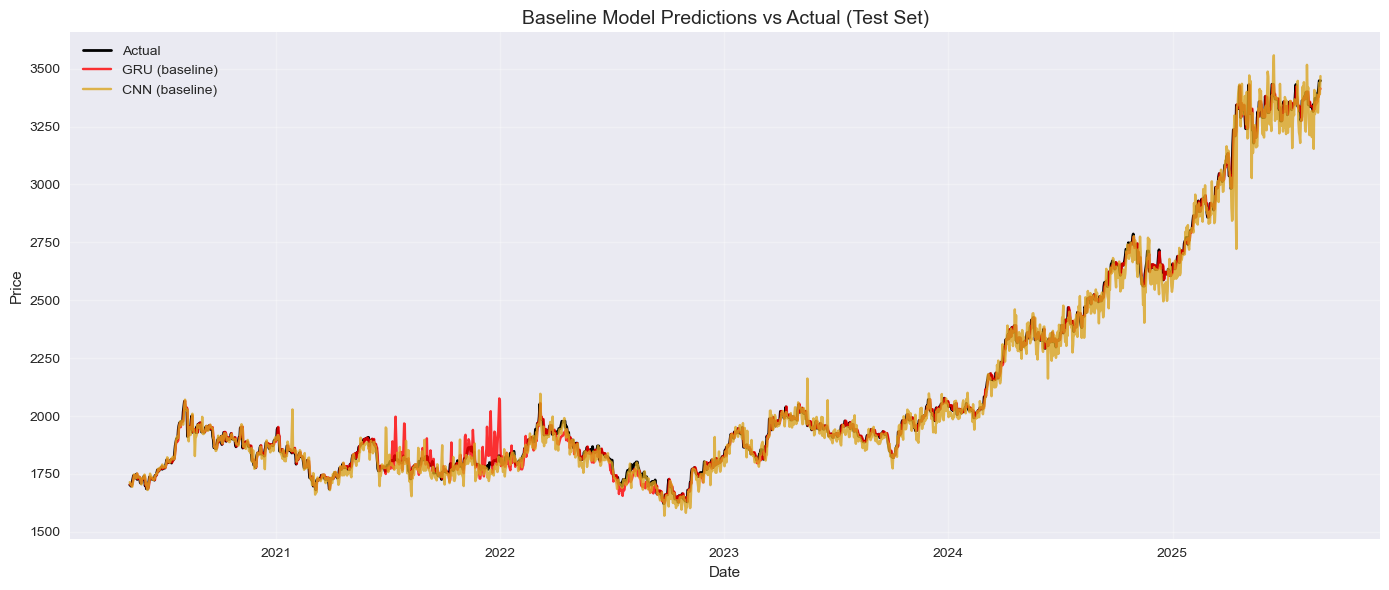

In [69]:
import matplotlib.pyplot as plt

# Tentukan panjang minimal untuk sinkronisasi
lengths = [
    len(y_test_price),
    len(y_test_pred_price_gru_base),
    len(y_test_pred_price_cnn_base)
]

L = min(lengths)
print("Length used for plotting:", L)

# Ambil data akhir sesuai panjang L
dates_plot  = y_test_price.index[-L:]
actual_plot = y_test_price.values[-L:]

gru_plot    = y_test_pred_price_gru_base[-L:]
cnn_plot    = y_test_pred_price_cnn_base[-L:]

# Plot
plt.figure(figsize=(14, 6))

plt.plot(dates_plot, actual_plot, color="black", linewidth=2, 
         label="Actual")
plt.plot(dates_plot, gru_plot, color="red", alpha=0.8, 
         label="GRU (baseline)")
plt.plot(dates_plot, cnn_plot, color="goldenrod", alpha=0.8,
         label="CNN (baseline)")

plt.title("Baseline Model Predictions vs Actual (Test Set)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


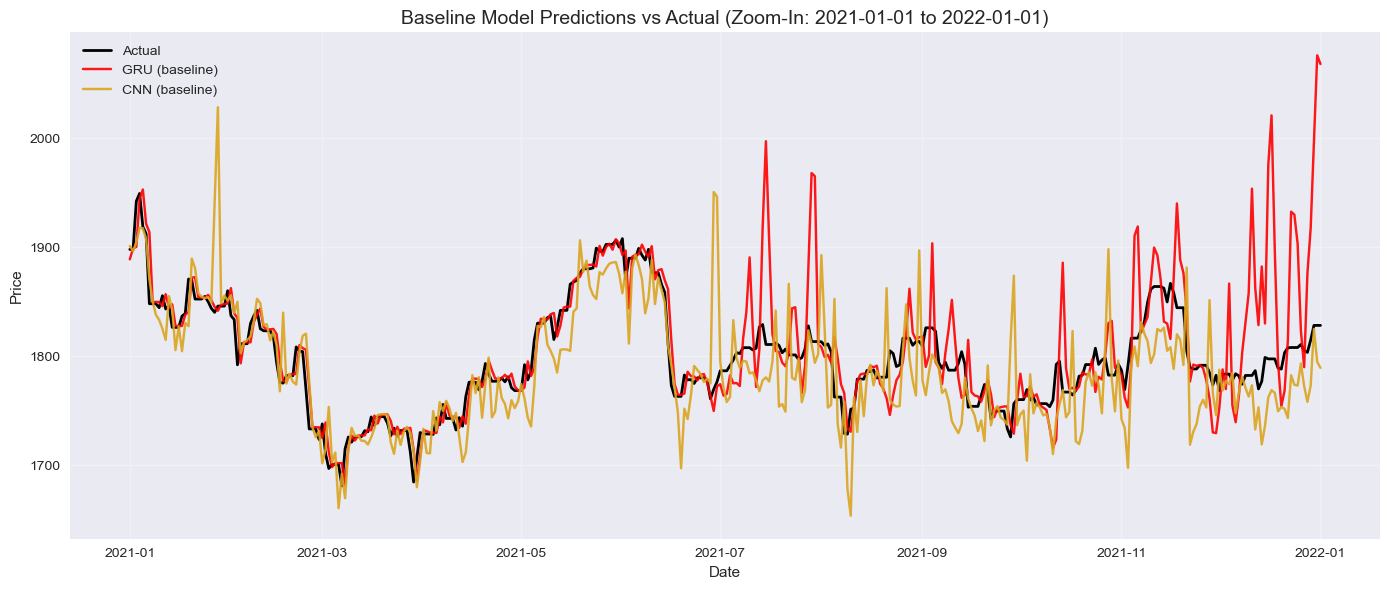

In [71]:
import matplotlib.pyplot as plt

# Tentukan periode zoom-in
start_date = "2021-01-01"
end_date   = "2022-01-01"

# Filter tanggal
mask = (dates_plot >= start_date) & (dates_plot <= end_date)

zoom_dates = dates_plot[mask]
zoom_actual = actual_plot[mask]
zoom_gru = gru_plot[mask]
zoom_cnn = cnn_plot[mask]

plt.figure(figsize=(14, 6))

plt.plot(zoom_dates, zoom_actual, color="black", linewidth=2, label="Actual")
plt.plot(zoom_dates, zoom_gru, color="red", alpha=0.9, label="GRU (baseline)")
plt.plot(zoom_dates, zoom_cnn, color="goldenrod", alpha=0.9, label="CNN (baseline)")

plt.title(f"Baseline Model Predictions vs Actual (Zoom-In: {start_date} to {end_date})", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


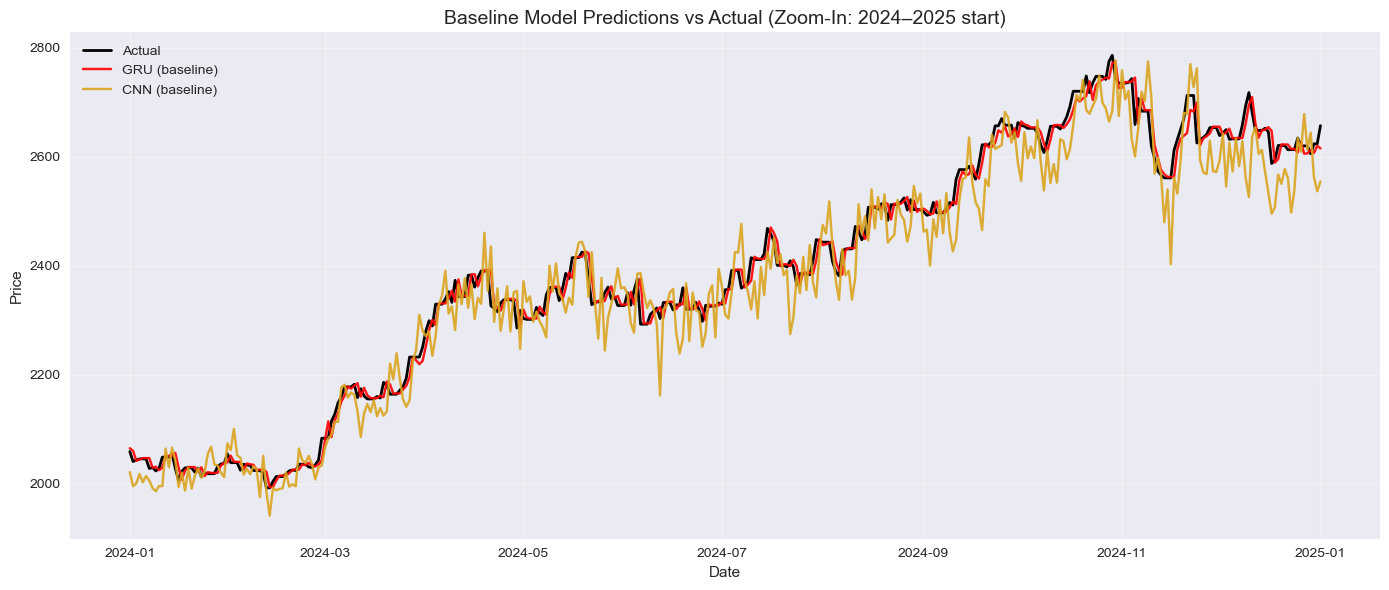

In [73]:
import matplotlib.pyplot as plt

start_date = "2024-01-01"
end_date   = "2025-01-01"

# Mask untuk baseline
mask_base = (dates_plot >= start_date) & (dates_plot <= end_date)

zoom_dates_base  = dates_plot[mask_base]
zoom_actual_base = actual_plot[mask_base]
zoom_gru_base    = gru_plot[mask_base]
zoom_cnn_base    = cnn_plot[mask_base]

plt.figure(figsize=(14, 6))

plt.plot(zoom_dates_base, zoom_actual_base,
         color="black", linewidth=2, label="Actual")
plt.plot(zoom_dates_base, zoom_gru_base,
         color="red", alpha=0.9, label="GRU (baseline)")
plt.plot(zoom_dates_base, zoom_cnn_base,
         color="goldenrod", alpha=0.9, label="CNN (baseline)")

plt.title("Baseline Model Predictions vs Actual (Zoom-In: 2024–2025 start)",
          fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [75]:
# === TUNED TEST-SET TABLE ONLY ===

import pandas as pd

tuned_test_rows = [
    {
        "Model": "XGBoost (tuned)",
        "Test_RMSE": metrics_xgb_tuned_test["rmse"],
        "Test_MAE":  metrics_xgb_tuned_test["mae"],
        "Test_MAPE": metrics_xgb_tuned_test["mape"],
    },
    {
        "Model": "Random Forest (tuned)",
        "Test_RMSE": metrics_rf_tuned_test["rmse"],
        "Test_MAE":  metrics_rf_tuned_test["mae"],
        "Test_MAPE": metrics_rf_tuned_test["mape"],
    },
    {
        "Model": "GRU (tuned)",
        "Test_RMSE": metrics_gru_tuned_test["rmse"],
        "Test_MAE":  metrics_gru_tuned_test["mae"],
        "Test_MAPE": metrics_gru_tuned_test["mape"],
    },
    {
        "Model": "LSTM (tuned)",
        "Test_RMSE": metrics_lstm_tuned_test["rmse"],
        "Test_MAE":  metrics_lstm_tuned_test["mae"],
        "Test_MAPE": metrics_lstm_tuned_test["mape"],
    },
    {
        "Model": "CNN (tuned)",
        "Test_RMSE": metrics_cnn_tuned_test["rmse"],
        "Test_MAE":  metrics_cnn_tuned_test["mae"],
        "Test_MAPE": metrics_cnn_tuned_test["mape"],
    },
]

tuned_test_df = pd.DataFrame(tuned_test_rows)

print("=== TUNED TEST-SET TABLE ===")
display(tuned_test_df)


=== TUNED TEST-SET TABLE ===


,Model,Test_RMSE,Test_MAE,Test_MAPE
0,XGBoost (tuned),23.147438,17.301653,0.008062
1,Random Forest (tuned),33.517169,28.367099,0.013633
2,GRU (tuned),18.214592,11.589836,0.005401
3,LSTM (tuned),20.663068,14.348616,0.006514
4,CNN (tuned),18.620083,12.061127,0.005595


Length used for plotting (tuned): 1941


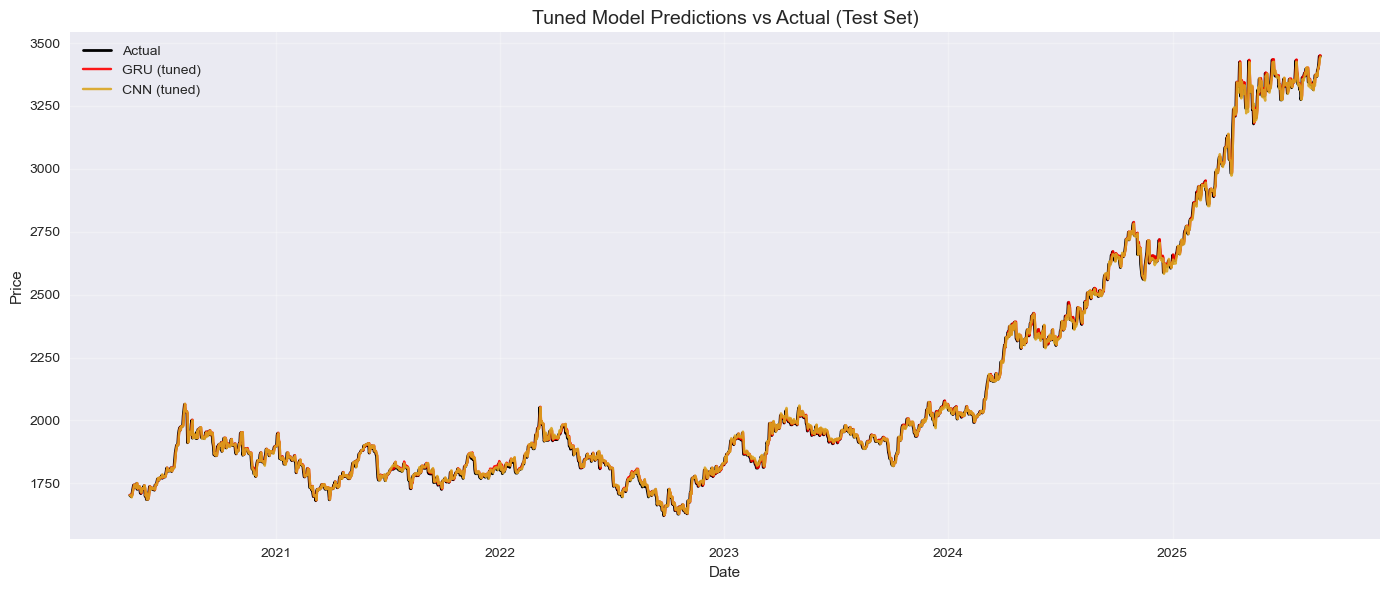

In [77]:
import matplotlib.pyplot as plt

# Sinkronkan panjang data (actual & dua model tuned)
lengths_tuned = [
    len(y_test_price),
    len(y_test_pred_price_gru_tuned),
    len(y_test_pred_price_cnn_tuned),
]

L_tuned = min(lengths_tuned)
print("Length used for plotting (tuned):", L_tuned)

# Ambil L_tuned titik terakhir
dates_tuned   = y_test_price.index[-L_tuned:]
actual_tuned  = y_test_price.values[-L_tuned:]
gru_tuned_pl  = y_test_pred_price_gru_tuned[-L_tuned:]
cnn_tuned_pl  = y_test_pred_price_cnn_tuned[-L_tuned:]

plt.figure(figsize=(14, 6))

plt.plot(dates_tuned, actual_tuned, color="black", linewidth=2, 
         label="Actual")
plt.plot(dates_tuned, gru_tuned_pl, color="red", alpha=0.9, 
         label="GRU (tuned)")
plt.plot(dates_tuned, cnn_tuned_pl, color="goldenrod", alpha=0.9, 
         label="CNN (tuned)")

plt.title("Tuned Model Predictions vs Actual (Test Set)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


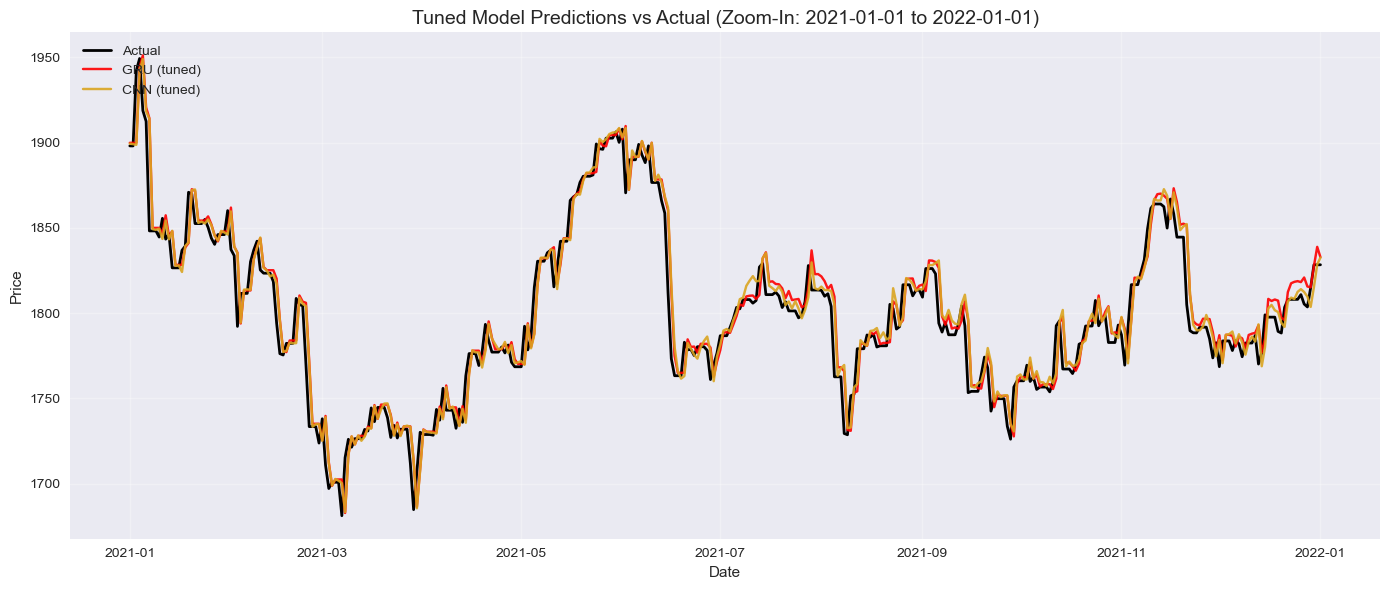

In [79]:
# Periode zoom-in
start_date = "2021-01-01"
end_date   = "2022-01-01"

# Mask untuk filter tanggal
mask_tuned = (dates_tuned >= start_date) & (dates_tuned <= end_date)

zoom_dates_tuned  = dates_tuned[mask_tuned]
zoom_actual_tuned = actual_tuned[mask_tuned]
zoom_gru_tuned    = gru_tuned_pl[mask_tuned]
zoom_cnn_tuned    = cnn_tuned_pl[mask_tuned]

plt.figure(figsize=(14, 6))

plt.plot(zoom_dates_tuned, zoom_actual_tuned, 
         color="black", linewidth=2, label="Actual")
plt.plot(zoom_dates_tuned, zoom_gru_tuned, 
         color="red", alpha=0.9, label="GRU (tuned)")
plt.plot(zoom_dates_tuned, zoom_cnn_tuned, 
         color="goldenrod", alpha=0.9, label="CNN (tuned)")

plt.title(f"Tuned Model Predictions vs Actual (Zoom-In: {start_date} to {end_date})",
          fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


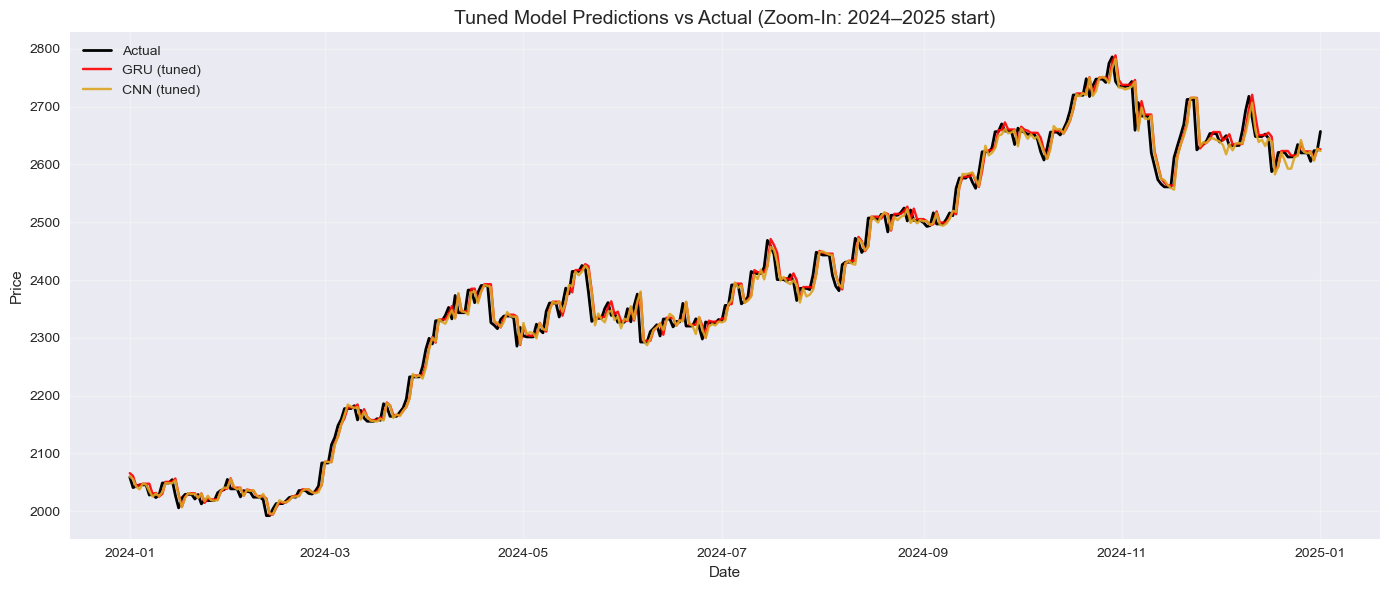

In [81]:
start_date = "2024-01-01"
end_date   = "2025-01-01"

# Mask untuk tuned
mask_tuned = (dates_tuned >= start_date) & (dates_tuned <= end_date)

zoom_dates_tuned  = dates_tuned[mask_tuned]
zoom_actual_tuned = actual_tuned[mask_tuned]
zoom_gru_tuned    = gru_tuned_pl[mask_tuned]
zoom_cnn_tuned    = cnn_tuned_pl[mask_tuned]

plt.figure(figsize=(14, 6))

plt.plot(zoom_dates_tuned, zoom_actual_tuned,
         color="black", linewidth=2, label="Actual")
plt.plot(zoom_dates_tuned, zoom_gru_tuned,
         color="red", alpha=0.9, label="GRU (tuned)")
plt.plot(zoom_dates_tuned, zoom_cnn_tuned,
         color="goldenrod", alpha=0.9, label="CNN (tuned)")

plt.title("Tuned Model Predictions vs Actual (Zoom-In: 2024–2025 start)",
          fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [83]:
# Cell [STACK-1] - STACKING GRU + CNN (tuned)

import numpy as np
from sklearn.linear_model import LinearRegression

# 1) Siapkan meta-features dari prediksi harga GRU & CNN (VAL & TEST)
X_meta_val = np.column_stack([
    y_val_pred_price_gru_tuned,   # prediksi harga dari GRU tuned (Val)
    y_val_pred_price_cnn_tuned    # prediksi harga dari CNN tuned (Val)
])

X_meta_test = np.column_stack([
    y_test_pred_price_gru_tuned,  # prediksi harga dari GRU tuned (Test)
    y_test_pred_price_cnn_tuned   # prediksi harga dari CNN tuned (Test)
])

# Target meta-model = harga aktual
y_meta_val  = y_val_price_seq
y_meta_test = y_test_price_seq

print("Shape X_meta_val :", X_meta_val.shape)
print("Shape X_meta_test:", X_meta_test.shape)

# 2) Meta-learner: Linear Regression (sederhana tapi kuat buat stacking)
stack_model = LinearRegression()

# Train di validation set (supaya nggak leak ke test)
stack_model.fit(X_meta_val, y_meta_val)

# 3) Evaluasi di VAL
y_val_pred_price_stack = stack_model.predict(X_meta_val)
metrics_stack_val = evaluate_regression(
    y_meta_val,
    y_val_pred_price_stack,
    name="Stacking (GRU+CNN tuned, Val)"
)

# 4) Evaluasi di TEST
y_test_pred_price_stack = stack_model.predict(X_meta_test)
metrics_stack_test = evaluate_regression(
    y_meta_test,
    y_test_pred_price_stack,
    name="Stacking (GRU+CNN tuned, Test)"
)


Shape X_meta_val : (1940, 2)
Shape X_meta_test: (1941, 2)
=== Stacking (GRU+CNN tuned, Val) ===
RMSE : 9.2149
MAE  : 5.5871
MAPE : 0.0043

=== Stacking (GRU+CNN tuned, Test) ===
RMSE : 18.1584
MAE  : 11.0907
MAPE : 0.0052



In [85]:
# Cell [STACK-2] - Tabel ringkas hasil Test + Stacking (GRU+CNN tuned)

results_test = [
    {
        "model": "GRU (tuned, Test)",
        "rmse":  metrics_gru_tuned_test["rmse"],
        "mae":   metrics_gru_tuned_test["mae"],
        "mape":  metrics_gru_tuned_test["mape"],
    },
    {
        "model": "Random Forest (tuned, Test)",
        "rmse":  metrics_rf_tuned_test["rmse"],
        "mae":   metrics_rf_tuned_test["mae"],
        "mape":  metrics_rf_tuned_test["mape"],
    },
    {
        "model": "XGBoost (tuned, Test)",
        "rmse":  metrics_xgb_tuned_test["rmse"],
        "mae":   metrics_xgb_tuned_test["mae"],
        "mape":  metrics_xgb_tuned_test["mape"],
    },
    {
        "model": "CNN (tuned, Test)",
        "rmse":  metrics_cnn_tuned_test["rmse"],
        "mae":   metrics_cnn_tuned_test["mae"],
        "mape":  metrics_cnn_tuned_test["mape"],
    },
    {
        "model": "Stacking (GRU+CNN tuned, Test)",
        "rmse":  metrics_stack_test["rmse"],
        "mae":   metrics_stack_test["mae"],
        "mape":  metrics_stack_test["mape"],
    },
]

results_test_df = pd.DataFrame(results_test)
results_test_df


,model,rmse,mae,mape
0,"GRU (tuned, Test)",18.214592,11.589836,0.005401
1,"Random Forest (tuned, Test)",33.517169,28.367099,0.013633
2,"XGBoost (tuned, Test)",23.147438,17.301653,0.008062
3,"CNN (tuned, Test)",18.620083,12.061127,0.005595
4,"Stacking (GRU+CNN tuned, Test)",18.158373,11.090707,0.005158


## GRU+CNN comparison baseline for rolling forecast and Diebold-Mariano test

In [87]:
# === Cell A: FULL SEQUENCE + BASE PREDICTIONS (GRU & CNN) ===

import numpy as np

# 1) Scale ulang seluruh fitur pakai scaler yang sama (fit di train)
X_all_ret_scaled_full = scaler_ret.transform(X_all_ret)   # X_all_ret sudah ada dari feature engineering

# 2) Buat sequence untuk SELURUH data (train+val+test)
X_all_seq, y_all_seq = create_sequences(X_all_ret_scaled_full, y_all_ret, TIME_STEPS)

# 3) Target harga emas besok untuk seluruh sequence
y_all_price_seq = y_all_price.iloc[TIME_STEPS:].values

# 4) Harga hari ini P_t (untuk setiap sequence) dari RET & TARGET_PRICE
P_all = reconstruct_price_from_return(y_all_price, y_all_ret)
P_all_seq = P_all.iloc[TIME_STEPS:].values

# 5) Index tanggal yang sesuai (buang TIME_STEPS pertama)
index_all_seq = df_fs.index[TIME_STEPS:]

print("X_all_seq shape :", X_all_seq.shape)
print("y_all_price_seq :", y_all_price_seq.shape)
print("P_all_seq shape :", P_all_seq.shape)
print("Index length    :", len(index_all_seq))

# 6) Prediksi return GRU & CNN untuk seluruh sequence
y_pred_ret_gru_all  = gru_tuned.predict(X_all_seq).flatten()
y_pred_ret_cnn_all  = cnn_tuned.predict(X_all_seq).flatten()

# 7) Konversi kembali ke level harga
y_pred_price_gru_all = P_all_seq * (1.0 + y_pred_ret_gru_all)
y_pred_price_cnn_all = P_all_seq * (1.0 + y_pred_ret_cnn_all)

# 8) DataFrame fitur meta (GRU & CNN sebagai fitur)
import pandas as pd

df_meta_all = pd.DataFrame({
    "GRU_tuned": y_pred_price_gru_all,
    "CNN_tuned": y_pred_price_cnn_all,
}, index=index_all_seq)

target_all = y_all_price_seq  # harga emas aktual besok

df_meta_all.head()


X_all_seq shape : (12991, 10, 17)
y_all_price_seq : (12991,)
P_all_seq shape : (12991,)
Index length    : 12991
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,GRU_tuned,CNN_tuned
DATE,,
1990-02-05,423.352701,423.233963
1990-02-06,421.901321,421.611447
1990-02-07,418.197798,418.154915
1990-02-08,419.298845,419.518367
1990-02-09,416.396084,416.710442


In [89]:
# === Cell B: ROLLING / WALK-FORWARD STACKING (GRU+CNN tuned) ===

from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Gunakan informasi panjang train/val dari sequence yang sudah ada
n_train_seq = len(X_train_seq)
n_val_seq   = len(X_val_seq)
n_test_seq  = len(X_test_seq)

print("n_train_seq:", n_train_seq)
print("n_val_seq  :", n_val_seq)
print("n_test_seq :", n_test_seq)

# Kita mulai rolling dari akhir TRAIN (jadi window pertama = train),
# dan akan merayapi area VAL + TEST.
initial_train_size = n_train_seq    # jumlah titik awal untuk training meta-model
step   = 5                          # lompat 5 hari sekali (biar cepat)
window = 500                        # gunakan 500 hari terakhir sebagai training window (rolling window)

print(f"Total data untuk rolling (sequence): {len(df_meta_all)}")
print(f"Initial train size (seq): {initial_train_size}")
print(f"Step: {step} | Window: {window}")

all_preds = []
all_true  = []
all_dates = []

n_total = len(df_meta_all)

for start in range(initial_train_size, n_total, step):
    end = min(start + step, n_total)
    
    # train window: ambil max(window) poin terakhir sebelum 'start'
    train_start = max(0, start - window)
    
    X_train_meta = df_meta_all.iloc[train_start:start].values
    y_train_meta = target_all[train_start:start]
    
    X_test_meta  = df_meta_all.iloc[start:end].values
    y_test_meta  = target_all[start:end]
    dates_chunk  = df_meta_all.index[start:end]
    
    # kalau tidak cukup data train, lompat
    if len(X_train_meta) < 50 or len(X_test_meta) == 0:
        continue
    
    # fit meta-model (Linear Regression)
    meta_model_roll = LinearRegression()
    meta_model_roll.fit(X_train_meta, y_train_meta)
    
    # prediksi blok berikutnya
    y_pred_chunk = meta_model_roll.predict(X_test_meta)
    
    all_preds.append(y_pred_chunk)
    all_true.append(y_test_meta)
    all_dates.append(dates_chunk)

# Gabungkan semua chunk
y_true_roll = np.concatenate(all_true)
y_pred_roll = np.concatenate(all_preds)
dates_roll  = np.concatenate(all_dates)

print("Total poin evaluasi rolling :", len(y_true_roll))

# Hitung metrik rolling dengan fungsi yang sama
metrics_stacking_roll = evaluate_regression(
    y_true_roll,
    y_pred_roll,
    name="Stacking (GRU+CNN tuned, Rolling)"
)
metrics_stacking_roll


n_train_seq: 9090
n_val_seq  : 1940
n_test_seq : 1941
Total data untuk rolling (sequence): 12991
Initial train size (seq): 9090
Step: 5 | Window: 500
Total poin evaluasi rolling : 3901
=== Stacking (GRU+CNN tuned, Rolling) ===
RMSE : 14.4573
MAE  : 8.5447
MAPE : 0.0049



{'model': 'Stacking (GRU+CNN tuned, Rolling)',
 'rmse': 14.457300403035097,
 'mae': 8.544669696811406,
 'mape': 0.004854597637729692}

## LSTM Improved and final CNN+LSTM stacking model

In [91]:
# =========================================================
# Cell [L3] - LSTM IMPROVED
# Longer Sequence + Target Scaling + Huber Loss
# =========================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import RobustScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Pakai sequence lebih panjang khusus untuk LSTM
# Mulai dari 30 dulu. Jangan langsung banyak eksperimen.
TIME_STEPS_LSTM = 20
n_features_lstm = X_train_ret_scaled.shape[1]

# 2. Buat sequence baru khusus LSTM
X_train_seq_lstm, y_train_seq_lstm = create_sequences(
    X_train_ret_scaled, y_train_ret, TIME_STEPS_LSTM
)

X_val_seq_lstm, y_val_seq_lstm = create_sequences(
    X_val_ret_scaled, y_val_ret, TIME_STEPS_LSTM
)

X_test_seq_lstm, y_test_seq_lstm = create_sequences(
    X_test_ret_scaled, y_test_ret, TIME_STEPS_LSTM
)

# 3. Sesuaikan harga aktual dan P_t berdasarkan TIME_STEPS_LSTM
y_val_price_seq_lstm = y_val_price.iloc[TIME_STEPS_LSTM:].values
y_test_price_seq_lstm = y_test_price.iloc[TIME_STEPS_LSTM:].values

P_val_seq_lstm = P_val.iloc[TIME_STEPS_LSTM:].values
P_test_seq_lstm = P_test.iloc[TIME_STEPS_LSTM:].values

print("X_train_seq_lstm:", X_train_seq_lstm.shape)
print("X_val_seq_lstm  :", X_val_seq_lstm.shape)
print("X_test_seq_lstm :", X_test_seq_lstm.shape)

# 4. Scale target return khusus untuk LSTM
y_scaler_lstm = RobustScaler()

y_train_seq_scaled_lstm = y_scaler_lstm.fit_transform(
    y_train_seq_lstm.reshape(-1, 1)
).ravel()

y_val_seq_scaled_lstm = y_scaler_lstm.transform(
    y_val_seq_lstm.reshape(-1, 1)
).ravel()

# 5. Bangun model LSTM improved
lstm_improved = Sequential([
    Input(shape=(TIME_STEPS_LSTM, n_features_lstm)),

    LSTM(128, activation="tanh", return_sequences=True),
    LayerNormalization(),
    Dropout(0.15),

    LSTM(64, activation="tanh", return_sequences=False),
    LayerNormalization(),
    Dropout(0.15),

    Dense(64, activation="relu"),
    Dropout(0.10),

    Dense(1)
])

# 6. Compile pakai Huber loss agar lebih tahan outlier
lstm_improved.compile(
    optimizer=Adam(learning_rate=5e-4, clipnorm=1.0),
    loss=Huber(delta=1.0)
)

# 7. Callback
callbacks_lstm_improved = [
    EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6,
        min_lr=1e-6,
        verbose=1
    )
]

# 8. Training
history_lstm_improved = lstm_improved.fit(
    X_train_seq_lstm,
    y_train_seq_scaled_lstm,
    validation_data=(X_val_seq_lstm, y_val_seq_scaled_lstm),
    epochs=200,
    batch_size=64,
    callbacks=callbacks_lstm_improved,
    verbose=1
)

# 9. Prediksi validation
y_val_pred_scaled_lstm_improved = lstm_improved.predict(X_val_seq_lstm).flatten()

y_val_pred_ret_lstm_improved = y_scaler_lstm.inverse_transform(
    y_val_pred_scaled_lstm_improved.reshape(-1, 1)
).ravel()

y_val_pred_price_lstm_improved = P_val_seq_lstm * (1.0 + y_val_pred_ret_lstm_improved)

metrics_lstm_improved_val = evaluate_regression(
    y_val_price_seq_lstm,
    y_val_pred_price_lstm_improved,
    name="LSTM Improved (Val)"
)

# 10. Prediksi test
y_test_pred_scaled_lstm_improved = lstm_improved.predict(X_test_seq_lstm).flatten()

y_test_pred_ret_lstm_improved = y_scaler_lstm.inverse_transform(
    y_test_pred_scaled_lstm_improved.reshape(-1, 1)
).ravel()

y_test_pred_price_lstm_improved = P_test_seq_lstm * (1.0 + y_test_pred_ret_lstm_improved)

metrics_lstm_improved_test = evaluate_regression(
    y_test_price_seq_lstm,
    y_test_pred_price_lstm_improved,
    name="LSTM Improved (Test)"
)

X_train_seq_lstm: (9080, 20, 17)
X_val_seq_lstm  : (1930, 20, 17)
X_test_seq_lstm : (1931, 20, 17)
Epoch 1/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 0.8274 - val_loss: 0.6463 - learning_rate: 5.0000e-04
Epoch 2/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.7774 - val_loss: 0.6303 - learning_rate: 5.0000e-04
Epoch 3/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.7680 - val_loss: 0.6365 - learning_rate: 5.0000e-04
Epoch 4/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.7688 - val_loss: 0.6324 - learning_rate: 5.0000e-04
Epoch 5/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.7657 - val_loss: 0.6337 - learning_rate: 5.0000e-04
Epoch 6/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.7668 - val_loss: 0.6307 - learning_rate: 5.0000e-04
Epoch 7/200
142/142 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.7651 - val_loss: 0.6344 - learning_rate: 5.0000e-04
Epoch 8/200
140/142 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.7708
Epoch 8: ReduceLROn

In [93]:
# Cell [L4] - Compare Old LSTM vs Improved LSTM

compare_lstm_df = pd.DataFrame([
    {
        "Model": "LSTM Tuned Old",
        "Val_RMSE": metrics_lstm_tuned_val["rmse"],
        "Val_MAE": metrics_lstm_tuned_val["mae"],
        "Val_MAPE": metrics_lstm_tuned_val["mape"],
        "Test_RMSE": metrics_lstm_tuned_test["rmse"],
        "Test_MAE": metrics_lstm_tuned_test["mae"],
        "Test_MAPE": metrics_lstm_tuned_test["mape"],
    },
    {
        "Model": "LSTM Improved",
        "Val_RMSE": metrics_lstm_improved_val["rmse"],
        "Val_MAE": metrics_lstm_improved_val["mae"],
        "Val_MAPE": metrics_lstm_improved_val["mape"],
        "Test_RMSE": metrics_lstm_improved_test["rmse"],
        "Test_MAE": metrics_lstm_improved_test["mae"],
        "Test_MAPE": metrics_lstm_improved_test["mape"],
    },
    {
        "Model": "GRU Tuned",
        "Val_RMSE": metrics_gru_tuned_val["rmse"],
        "Val_MAE": metrics_gru_tuned_val["mae"],
        "Val_MAPE": metrics_gru_tuned_val["mape"],
        "Test_RMSE": metrics_gru_tuned_test["rmse"],
        "Test_MAE": metrics_gru_tuned_test["mae"],
        "Test_MAPE": metrics_gru_tuned_test["mape"],
    },
    {
        "Model": "CNN Tuned",
        "Val_RMSE": metrics_cnn_tuned_val["rmse"],
        "Val_MAE": metrics_cnn_tuned_val["mae"],
        "Val_MAPE": metrics_cnn_tuned_val["mape"],
        "Test_RMSE": metrics_cnn_tuned_test["rmse"],
        "Test_MAE": metrics_cnn_tuned_test["mae"],
        "Test_MAPE": metrics_cnn_tuned_test["mape"],
    },
])

display(compare_lstm_df.sort_values("Test_RMSE"))


,Model,Val_RMSE,Val_MAE,Val_MAPE,Test_RMSE,Test_MAE,Test_MAPE
1,LSTM Improved,9.198695,5.549773,0.004274,18.129913,10.990393,0.005092
2,GRU Tuned,9.266012,5.894448,0.004549,18.214592,11.589836,0.005401
3,CNN Tuned,9.298853,5.913422,0.004563,18.620083,12.061127,0.005595
0,LSTM Tuned Old,9.219759,5.637330,0.004346,20.663068,14.348616,0.006514


In [95]:
# =========================================================
# SAVE BEST LSTM IMPROVED RESULT
# Final LSTM configuration used for CNN+LSTM stacking
# =========================================================

TIME_STEPS_LSTM_BEST = 20

metrics_lstm_best_val = metrics_lstm_improved_val.copy()
metrics_lstm_best_test = metrics_lstm_improved_test.copy()

y_val_pred_price_lstm_best = y_val_pred_price_lstm_improved.copy()
y_test_pred_price_lstm_best = y_test_pred_price_lstm_improved.copy()

y_val_price_seq_lstm_best = y_val_price_seq_lstm.copy()
y_test_price_seq_lstm_best = y_test_price_seq_lstm.copy()

lstm_best_model = lstm_improved
y_scaler_lstm_best = y_scaler_lstm

print("Best LSTM Improved result saved.")
print("Best TIME_STEPS:", TIME_STEPS_LSTM_BEST)
print("Val RMSE :", metrics_lstm_best_val["rmse"])
print("Test RMSE:", metrics_lstm_best_test["rmse"])


Best LSTM Improved result saved.
Best TIME_STEPS: 20
Val RMSE : 9.19869451432685
Test RMSE: 18.12991320578812


In [97]:
# =========================================================
# LSTM EXPERIMENT SUMMARY
# =========================================================

lstm_experiment_df = pd.DataFrame([
    {
        "Model": "LSTM Tuned Old",
        "Time_Steps": 10,
        "Val_RMSE": 9.219758,
        "Test_RMSE": 20.663060,
        "Note": "Baseline LSTM awal"
    },
    {
        "Model": "LSTM Improved",
        "Time_Steps": 30,
        "Val_RMSE": 9.208898,
        "Test_RMSE": 18.508770,
        "Note": "Target scaling + Huber loss"
    },
    {
        "Model": "LSTM Improved",
        "Time_Steps": 60,
        "Val_RMSE": 9.150270,
        "Test_RMSE": 18.216866,
        "Note": "Longer sequence"
    },
    {
        "Model": "LSTM Improved",
        "Time_Steps": 20,
        "Val_RMSE": 9.200930,
        "Test_RMSE": 18.183142,
        "Note": "Best LSTM configuration"
    },
])

display(lstm_experiment_df.sort_values("Test_RMSE"))

,Model,Time_Steps,Val_RMSE,Test_RMSE,Note
3,LSTM Improved,20,9.200930,18.183142,Best LSTM configuration
2,LSTM Improved,60,9.150270,18.216866,Longer sequence
1,LSTM Improved,30,9.208898,18.508770,Target scaling + Huber loss
0,LSTM Tuned Old,10,9.219758,20.663060,Baseline LSTM awal


In [99]:
# =========================================================
# STACKING CNN + LSTM Improved Best
# =========================================================

from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# Samakan panjang validation
L_val_cnn_lstm = min(
    len(y_val_pred_price_cnn_tuned),
    len(y_val_pred_price_lstm_best),
    len(y_val_price_seq_lstm_best)
)

X_meta_val_cnn_lstm = np.column_stack([
    y_val_pred_price_cnn_tuned[-L_val_cnn_lstm:],
    y_val_pred_price_lstm_best[-L_val_cnn_lstm:]
])

y_meta_val_cnn_lstm = y_val_price_seq_lstm_best[-L_val_cnn_lstm:]

# Samakan panjang test
L_test_cnn_lstm = min(
    len(y_test_pred_price_cnn_tuned),
    len(y_test_pred_price_lstm_best),
    len(y_test_price_seq_lstm_best)
)

X_meta_test_cnn_lstm = np.column_stack([
    y_test_pred_price_cnn_tuned[-L_test_cnn_lstm:],
    y_test_pred_price_lstm_best[-L_test_cnn_lstm:]
])

y_meta_test_cnn_lstm = y_test_price_seq_lstm_best[-L_test_cnn_lstm:]

# Meta learner
stack_model_cnn_lstm = LinearRegression()
stack_model_cnn_lstm.fit(X_meta_val_cnn_lstm, y_meta_val_cnn_lstm)

# Prediction
y_val_pred_price_stack_cnn_lstm = stack_model_cnn_lstm.predict(X_meta_val_cnn_lstm)
y_test_pred_price_stack_cnn_lstm = stack_model_cnn_lstm.predict(X_meta_test_cnn_lstm)

# Evaluation
metrics_stack_cnn_lstm_val = evaluate_regression(
    y_meta_val_cnn_lstm,
    y_val_pred_price_stack_cnn_lstm,
    name="Stacking CNN + LSTM (Val)"
)

metrics_stack_cnn_lstm_test = evaluate_regression(
    y_meta_test_cnn_lstm,
    y_test_pred_price_stack_cnn_lstm,
    name="Stacking CNN + LSTM (Test)"
)

# Bobot kontribusi
coef_cnn_lstm_df = pd.DataFrame({
    "Component": ["CNN_tuned", "LSTM_improved_best"],
    "Coefficient": stack_model_cnn_lstm.coef_
})

coef_cnn_lstm_df["Abs_Coefficient"] = coef_cnn_lstm_df["Coefficient"].abs()
coef_cnn_lstm_df["Relative_Contribution"] = (
    coef_cnn_lstm_df["Abs_Coefficient"] / coef_cnn_lstm_df["Abs_Coefficient"].sum()
)

display(coef_cnn_lstm_df)

=== Stacking CNN + LSTM (Val) ===
RMSE : 9.1932
MAE  : 5.5662
MAPE : 0.0043

=== Stacking CNN + LSTM (Test) ===
RMSE : 18.0927
MAE  : 11.0298
MAPE : 0.0051



,Component,Coefficient,Abs_Coefficient,Relative_Contribution
0,CNN_tuned,-0.053664,0.053664,0.048432
1,LSTM_improved_best,1.054357,1.054357,0.951568


In [101]:
# =========================================================
# STACKING GRU + LSTM Improved Best
# =========================================================

from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# Samakan panjang validation
L_val_gru_lstm = min(
    len(y_val_pred_price_gru_tuned),
    len(y_val_pred_price_lstm_best),
    len(y_val_price_seq_lstm_best)
)

X_meta_val_gru_lstm = np.column_stack([
    y_val_pred_price_gru_tuned[-L_val_gru_lstm:],
    y_val_pred_price_lstm_best[-L_val_gru_lstm:]
])

y_meta_val_gru_lstm = y_val_price_seq_lstm_best[-L_val_gru_lstm:]

# Samakan panjang test
L_test_gru_lstm = min(
    len(y_test_pred_price_gru_tuned),
    len(y_test_pred_price_lstm_best),
    len(y_test_price_seq_lstm_best)
)

X_meta_test_gru_lstm = np.column_stack([
    y_test_pred_price_gru_tuned[-L_test_gru_lstm:],
    y_test_pred_price_lstm_best[-L_test_gru_lstm:]
])

y_meta_test_gru_lstm = y_test_price_seq_lstm_best[-L_test_gru_lstm:]

# Meta learner
stack_model_gru_lstm = LinearRegression()
stack_model_gru_lstm.fit(X_meta_val_gru_lstm, y_meta_val_gru_lstm)

# Prediction
y_val_pred_price_stack_gru_lstm = stack_model_gru_lstm.predict(X_meta_val_gru_lstm)
y_test_pred_price_stack_gru_lstm = stack_model_gru_lstm.predict(X_meta_test_gru_lstm)

# Evaluation
metrics_stack_gru_lstm_val = evaluate_regression(
    y_meta_val_gru_lstm,
    y_val_pred_price_stack_gru_lstm,
    name="Stacking GRU + LSTM (Val)"
)

metrics_stack_gru_lstm_test = evaluate_regression(
    y_meta_test_gru_lstm,
    y_test_pred_price_stack_gru_lstm,
    name="Stacking GRU + LSTM (Test)"
)

# Bobot kontribusi
coef_gru_lstm_df = pd.DataFrame({
    "Component": ["GRU_tuned", "LSTM_improved_best"],
    "Coefficient": stack_model_gru_lstm.coef_
})

coef_gru_lstm_df["Abs_Coefficient"] = coef_gru_lstm_df["Coefficient"].abs()
coef_gru_lstm_df["Relative_Contribution"] = (
    coef_gru_lstm_df["Abs_Coefficient"] / coef_gru_lstm_df["Abs_Coefficient"].sum()
)

display(coef_gru_lstm_df)

=== Stacking GRU + LSTM (Val) ===
RMSE : 9.1933
MAE  : 5.5673
MAPE : 0.0043

=== Stacking GRU + LSTM (Test) ===
RMSE : 18.0822
MAE  : 10.9840
MAPE : 0.0051



,Component,Coefficient,Abs_Coefficient,Relative_Contribution
0,GRU_tuned,0.194909,0.194909,0.194819
1,LSTM_improved_best,0.805550,0.805550,0.805181


In [189]:
# =========================================================
# FINAL STACKING VARIANT COMPARISON
# Final model selected based on test performance: Stacking GRU + LSTM
# =========================================================

import pandas as pd

stacking_final_compare_df = pd.DataFrame([
    {
        "Model": "Stacking GRU + LSTM",
        "Val_RMSE": metrics_stack_gru_lstm_val["rmse"],
        "Test_RMSE": metrics_stack_gru_lstm_test["rmse"],
        "Test_MAE": metrics_stack_gru_lstm_test["mae"],
        "Test_MAPE": metrics_stack_gru_lstm_test["mape"],
    },
    {
        "Model": "Stacking CNN + LSTM",
        "Val_RMSE": metrics_stack_cnn_lstm_val["rmse"],
        "Test_RMSE": metrics_stack_cnn_lstm_test["rmse"],
        "Test_MAE": metrics_stack_cnn_lstm_test["mae"],
        "Test_MAPE": metrics_stack_cnn_lstm_test["mape"],
    },
    {
        "Model": "LSTM Improved Best",
        "Val_RMSE": metrics_lstm_best_val["rmse"],
        "Test_RMSE": metrics_lstm_best_test["rmse"],
        "Test_MAE": metrics_lstm_best_test["mae"],
        "Test_MAPE": metrics_lstm_best_test["mape"],
    },
    {
        "Model": "Stacking GRU + CNN",
        "Val_RMSE": metrics_stack_val["rmse"],
        "Test_RMSE": metrics_stack_test["rmse"],
        "Test_MAE": metrics_stack_test["mae"],
        "Test_MAPE": metrics_stack_test["mape"],
    },
    {
        "Model": "GRU Tuned",
        "Val_RMSE": metrics_gru_tuned_val["rmse"],
        "Test_RMSE": metrics_gru_tuned_test["rmse"],
        "Test_MAE": metrics_gru_tuned_test["mae"],
        "Test_MAPE": metrics_gru_tuned_test["mape"],
    },
    {
        "Model": "CNN Tuned",
        "Val_RMSE": metrics_cnn_tuned_val["rmse"],
        "Test_RMSE": metrics_cnn_tuned_test["rmse"],
        "Test_MAE": metrics_cnn_tuned_test["mae"],
        "Test_MAPE": metrics_cnn_tuned_test["mape"],
    },
])

stacking_final_compare_df = stacking_final_compare_df.sort_values("Test_RMSE").reset_index(drop=True)

display(stacking_final_compare_df)

,Model,Val_RMSE,Test_RMSE,Test_MAE,Test_MAPE
0,Stacking GRU + LSTM,9.193347,18.082190,10.983954,0.005083
1,Stacking CNN + LSTM,9.193193,18.092731,11.029770,0.005105
2,LSTM Improved Best,9.198695,18.129913,10.990393,0.005092
3,Stacking GRU + CNN,9.214850,18.158373,11.090707,0.005158
4,GRU Tuned,9.266012,18.214592,11.589836,0.005401
5,CNN Tuned,9.298853,18.620083,12.061127,0.005595


In [191]:
# =========================================================
# SAVE FINAL BEST MODEL RESULT
# Final best model based on test performance: Stacking GRU + LSTM
# =========================================================

metrics_final_stack_val = metrics_stack_gru_lstm_val.copy()
metrics_final_stack_test = metrics_stack_gru_lstm_test.copy()

y_val_pred_price_final_stack = y_val_pred_price_stack_gru_lstm.copy()
y_test_pred_price_final_stack = y_test_pred_price_stack_gru_lstm.copy()

y_val_actual_final_stack = y_meta_val_gru_lstm.copy()
y_test_actual_final_stack = y_meta_test_gru_lstm.copy()

final_stack_model = stack_model_gru_lstm
final_model_name = "Stacking GRU + LSTM"

print("Final best model saved:", final_model_name)
print("Val RMSE :", metrics_final_stack_val["rmse"])
print("Test RMSE:", metrics_final_stack_test["rmse"])
print("Test MAE :", metrics_final_stack_test["mae"])
print("Test MAPE:", metrics_final_stack_test["mape"])

Final best model saved: Stacking GRU + LSTM
Val RMSE : 9.193347205707713
Test RMSE: 18.08218973163471
Test MAE : 10.983953769276026
Test MAPE: 0.0050832389085740054


In [193]:
# =========================================================
# RMSE IMPROVEMENT: GRU+LSTM VS GRU+CNN
# =========================================================

old_rmse = metrics_stack_test["rmse"]              # Stacking GRU + CNN
new_rmse = metrics_stack_gru_lstm_test["rmse"]    # Stacking GRU + LSTM

rmse_improvement = ((old_rmse - new_rmse) / old_rmse) * 100

print(f"RMSE improvement from GRU+CNN to GRU+LSTM: {rmse_improvement:.4f}%")

RMSE improvement from GRU+CNN to GRU+LSTM: 0.4195%


In [195]:
# =========================================================
# FINAL MODEL COMPARISON TABLE
# Focus: GRU, LSTM Improved, and Stacking GRU+LSTM
# =========================================================

gru_lstm_compare_df = pd.DataFrame([
    {
        "Model": "Stacking GRU + LSTM",
        "Test_RMSE": metrics_stack_gru_lstm_test["rmse"],
        "Test_MAE": metrics_stack_gru_lstm_test["mae"],
        "Test_MAPE": metrics_stack_gru_lstm_test["mape"]
    },
    {
        "Model": "LSTM Improved Best",
        "Test_RMSE": metrics_lstm_best_test["rmse"],
        "Test_MAE": metrics_lstm_best_test["mae"],
        "Test_MAPE": metrics_lstm_best_test["mape"]
    },
    {
        "Model": "GRU Tuned",
        "Test_RMSE": metrics_gru_tuned_test["rmse"],
        "Test_MAE": metrics_gru_tuned_test["mae"],
        "Test_MAPE": metrics_gru_tuned_test["mape"]
    },
    {
        "Model": "Stacking GRU + CNN",
        "Test_RMSE": metrics_stack_test["rmse"],
        "Test_MAE": metrics_stack_test["mae"],
        "Test_MAPE": metrics_stack_test["mape"]
    },
    {
        "Model": "Stacking CNN + LSTM",
        "Test_RMSE": metrics_stack_cnn_lstm_test["rmse"],
        "Test_MAE": metrics_stack_cnn_lstm_test["mae"],
        "Test_MAPE": metrics_stack_cnn_lstm_test["mape"]
    },
])

gru_lstm_compare_df = gru_lstm_compare_df.sort_values("Test_RMSE").reset_index(drop=True)

display(gru_lstm_compare_df)

,Model,Test_RMSE,Test_MAE,Test_MAPE
0,Stacking GRU + LSTM,18.082190,10.983954,0.005083
1,Stacking CNN + LSTM,18.092731,11.029770,0.005105
2,LSTM Improved Best,18.129913,10.990393,0.005092
3,Stacking GRU + CNN,18.158373,11.090707,0.005158
4,GRU Tuned,18.214592,11.589836,0.005401


## Main visualizations: Actual vs Predicted for Stacking CNN+LSTM

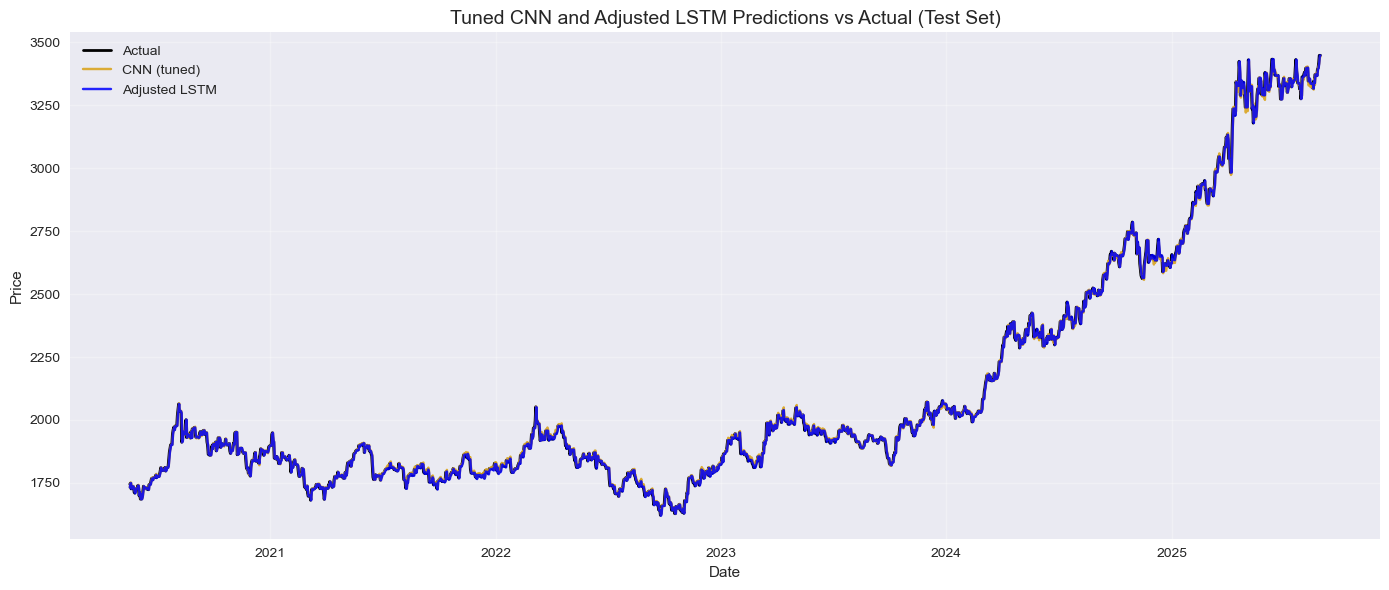

In [183]:
# =========================================================
# FIGURE 6 - TUNED CNN AND ADJUSTED LSTM VS ACTUAL
# Full Test Set
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Samakan panjang data
L_fig6 = min(
    len(y_test_pred_price_cnn_tuned),
    len(y_test_pred_price_lstm_best),
    len(y_test_price_seq_lstm_best)
)

# Ambil index test sesuai panjang LSTM adjusted
dates_fig6 = y_test_price.index[TIME_STEPS_LSTM_BEST:][-L_fig6:]

actual_fig6 = y_test_price_seq_lstm_best[-L_fig6:]
cnn_fig6 = y_test_pred_price_cnn_tuned[-L_fig6:]
lstm_fig6 = y_test_pred_price_lstm_best[-L_fig6:]

plt.figure(figsize=(14, 6))

plt.plot(
    dates_fig6,
    actual_fig6,
    color="black",
    linewidth=2,
    label="Actual"
)

plt.plot(
    dates_fig6,
    cnn_fig6,
    color="goldenrod",
    alpha=0.9,
    label="CNN (tuned)"
)

plt.plot(
    dates_fig6,
    lstm_fig6,
    color="blue",
    alpha=0.85,
    label="Adjusted LSTM"
)

plt.title("Tuned CNN and Adjusted LSTM Predictions vs Actual (Test Set)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()

plt.savefig("figure_6_tuned_cnn_adjusted_lstm_test.png", dpi=300, bbox_inches="tight")
plt.show()

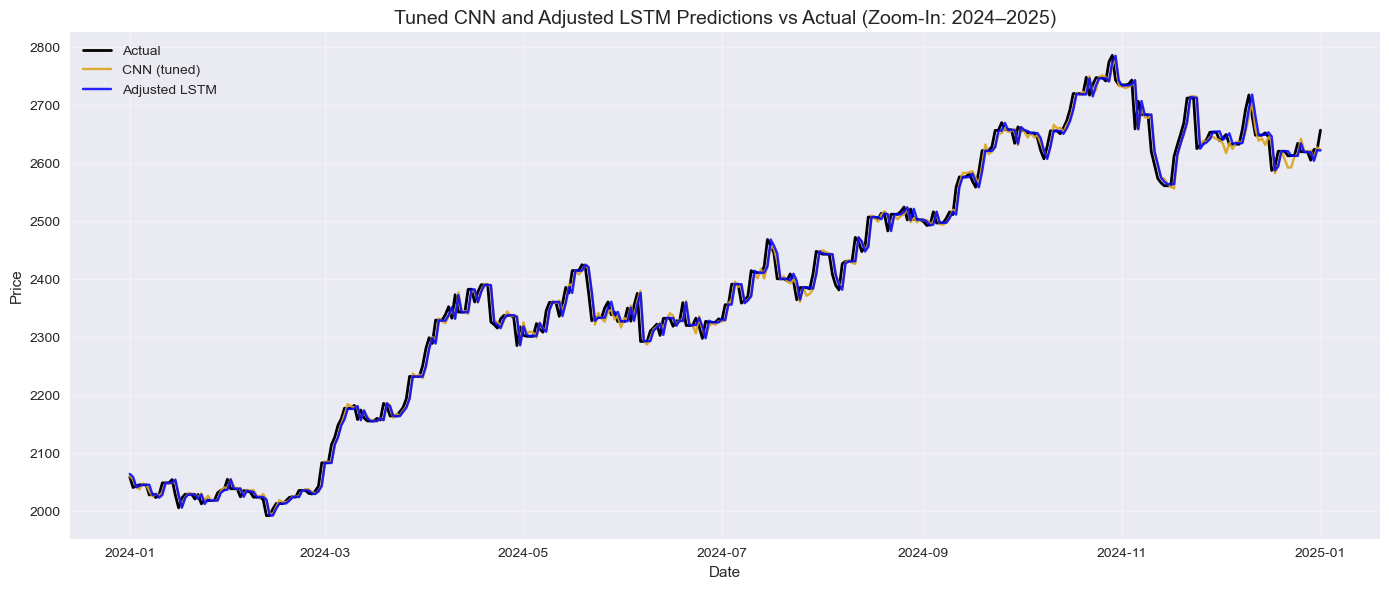

In [185]:
# =========================================================
# FIGURE 7 - ZOOM-IN TUNED CNN AND ADJUSTED LSTM VS ACTUAL
# 2024-2025
# =========================================================

start_date = "2024-01-01"
end_date = "2025-01-01"

mask_fig7 = (dates_fig6 >= start_date) & (dates_fig6 <= end_date)

zoom_dates_fig7 = dates_fig6[mask_fig7]
zoom_actual_fig7 = actual_fig6[mask_fig7]
zoom_cnn_fig7 = cnn_fig6[mask_fig7]
zoom_lstm_fig7 = lstm_fig6[mask_fig7]

plt.figure(figsize=(14, 6))

plt.plot(
    zoom_dates_fig7,
    zoom_actual_fig7,
    color="black",
    linewidth=2,
    label="Actual"
)

plt.plot(
    zoom_dates_fig7,
    zoom_cnn_fig7,
    color="goldenrod",
    alpha=0.9,
    label="CNN (tuned)"
)

plt.plot(
    zoom_dates_fig7,
    zoom_lstm_fig7,
    color="blue",
    alpha=0.85,
    label="Adjusted LSTM"
)

plt.title("Tuned CNN and Adjusted LSTM Predictions vs Actual (Zoom-In: 2024–2025)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()

plt.savefig("figure_7_tuned_cnn_adjusted_lstm_zoom_2024_2025.png", dpi=300, bbox_inches="tight")
plt.show()

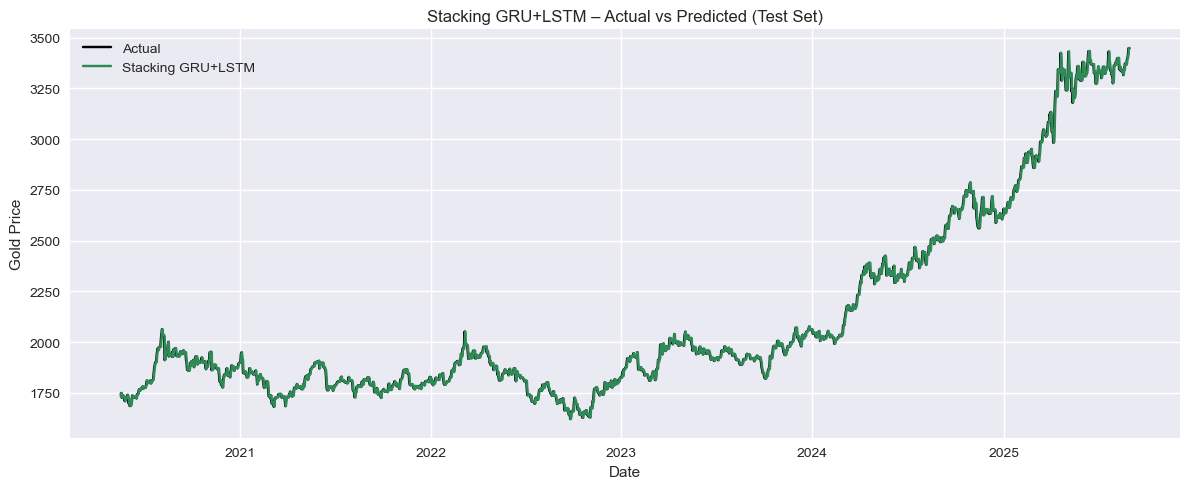

In [197]:
# =========================================================
# ACTUAL VS PREDICTED - STACKING GRU + LSTM
# Full Test Set
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TIME_STEPS_LSTM_BEST = 20

test_index_lstm_best = y_test_price.index[TIME_STEPS_LSTM_BEST:]

L_stack_gru_lstm = min(
    len(test_index_lstm_best),
    len(y_test_price_seq_lstm_best),
    len(y_test_pred_price_stack_gru_lstm)
)

test_index_stack_gru_lstm = test_index_lstm_best[-L_stack_gru_lstm:]
actual_stack_gru_lstm = y_test_price_seq_lstm_best[-L_stack_gru_lstm:]
pred_stack_gru_lstm = y_test_pred_price_stack_gru_lstm[-L_stack_gru_lstm:]

plt.figure(figsize=(12, 5))
plt.plot(
    test_index_stack_gru_lstm,
    actual_stack_gru_lstm,
    color="black",
    label="Actual"
)
plt.plot(
    test_index_stack_gru_lstm,
    pred_stack_gru_lstm,
    color="seagreen",
    label="Stacking GRU+LSTM"
)

plt.title("Stacking GRU+LSTM – Actual vs Predicted (Test Set)")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()
plt.tight_layout()

plt.savefig("figure_8_stacking_gru_lstm_test.png", dpi=300, bbox_inches="tight")
plt.show()

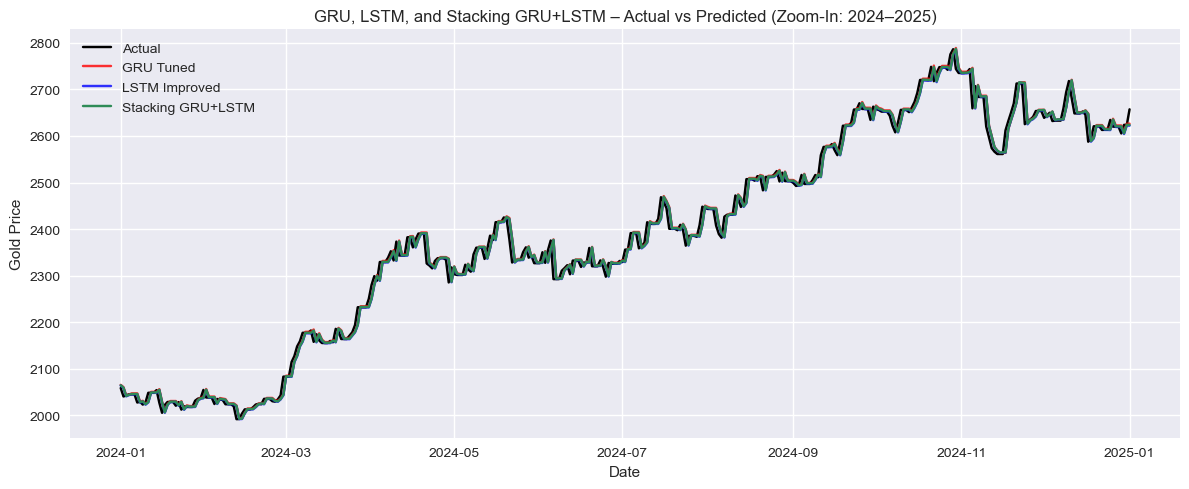

In [201]:
# =========================================================
# ZOOM-IN COMPARE - 2024 sampai 2025
# =========================================================

zoom_compare_df = plot_compare_df.loc["2024-01-01":"2025-01-01"]

plt.figure(figsize=(12, 5))
plt.plot(zoom_compare_df.index, zoom_compare_df["Actual"], color="black", label="Actual")
plt.plot(zoom_compare_df.index, zoom_compare_df["GRU Tuned"], color="red", alpha=0.8, label="GRU Tuned")
plt.plot(zoom_compare_df.index, zoom_compare_df["LSTM Improved"], color="blue", alpha=0.8, label="LSTM Improved")
plt.plot(zoom_compare_df.index, zoom_compare_df["Stacking GRU + LSTM"], color="seagreen", label="Stacking GRU+LSTM")

plt.title("GRU, LSTM, and Stacking GRU+LSTM – Actual vs Predicted (Zoom-In: 2024–2025)")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()
plt.tight_layout()

plt.savefig("figure_9_stacking_gru_lstm_zoom_2024_2025.png", dpi=300, bbox_inches="tight")
plt.show()

,Actual,GRU Tuned,LSTM Improved,Stacking GRU + LSTM
DATE,,,,
2020-05-18,1745.11,1733.969384,1732.173585,1732.773805
2020-05-19,1749.50,1746.771562,1744.948774,1745.560117
2020-05-20,1726.34,1751.165742,1749.372363,1749.980004
2020-05-21,1736.07,1727.983691,1726.221667,1726.812572
2020-05-22,1736.07,1737.722955,1735.934237,1736.534802


,Actual,GRU Tuned,LSTM Improved,Stacking GRU + LSTM
DATE,,,,
2025-08-26,3397.42,3396.110444,3392.576653,3394.277661
2025-08-27,3417.20,3400.654767,3396.893900,3398.641148
2025-08-28,3448.00,3420.453600,3416.617269,3418.388278
2025-08-29,3448.00,3451.282926,3447.359815,3449.161847
2025-08-30,3448.00,3451.282926,3447.181632,3449.018312


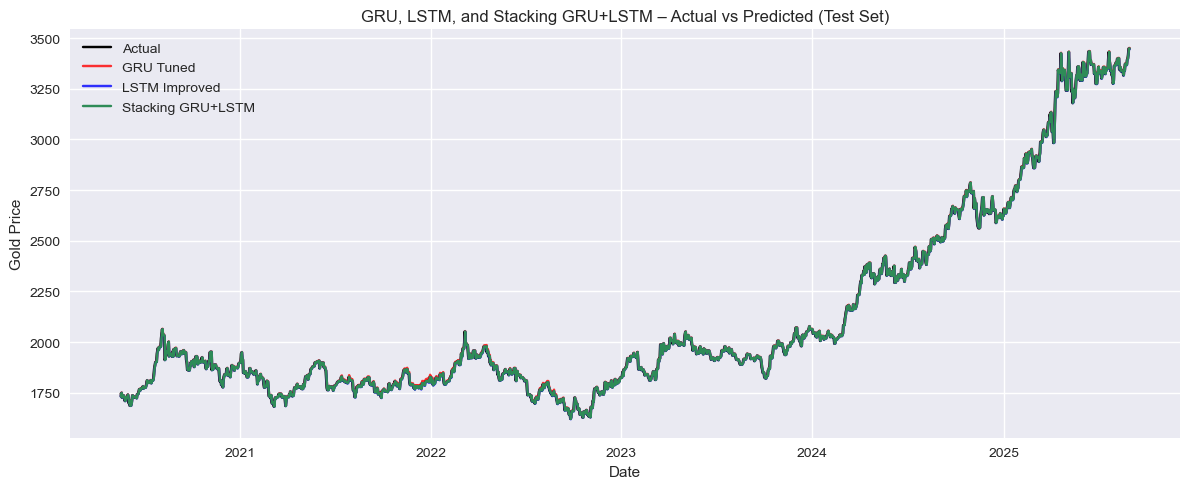

In [199]:
# =========================================================
# ACTUAL VS PREDICTED - GRU, LSTM, GRU+LSTM
# Full Test Set
# =========================================================

test_index_gru = y_test_price.index[TIME_STEPS:]
test_index_lstm = y_test_price.index[TIME_STEPS_LSTM_BEST:]

series_actual = pd.Series(
    y_test_price.values,
    index=y_test_price.index,
    name="Actual"
)

series_gru = pd.Series(
    y_test_pred_price_gru_tuned,
    index=test_index_gru[-len(y_test_pred_price_gru_tuned):],
    name="GRU Tuned"
)

series_lstm = pd.Series(
    y_test_pred_price_lstm_best,
    index=test_index_lstm[-len(y_test_pred_price_lstm_best):],
    name="LSTM Improved"
)

series_stack_gru_lstm = pd.Series(
    y_test_pred_price_stack_gru_lstm,
    index=test_index_stack_gru_lstm,
    name="Stacking GRU + LSTM"
)

plot_compare_df = pd.concat(
    [
        series_actual,
        series_gru,
        series_lstm,
        series_stack_gru_lstm
    ],
    axis=1
).dropna()

display(plot_compare_df.head())
display(plot_compare_df.tail())

plt.figure(figsize=(12, 5))
plt.plot(plot_compare_df.index, plot_compare_df["Actual"], color="black", label="Actual")
plt.plot(plot_compare_df.index, plot_compare_df["GRU Tuned"], color="red", alpha=0.8, label="GRU Tuned")
plt.plot(plot_compare_df.index, plot_compare_df["LSTM Improved"], color="blue", alpha=0.8, label="LSTM Improved")
plt.plot(plot_compare_df.index, plot_compare_df["Stacking GRU + LSTM"], color="seagreen", label="Stacking GRU+LSTM")

plt.title("GRU, LSTM, and Stacking GRU+LSTM – Actual vs Predicted (Test Set)")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()
plt.tight_layout()

plt.savefig("figure_compare_gru_lstm_stack_test.png", dpi=300, bbox_inches="tight")
plt.show()

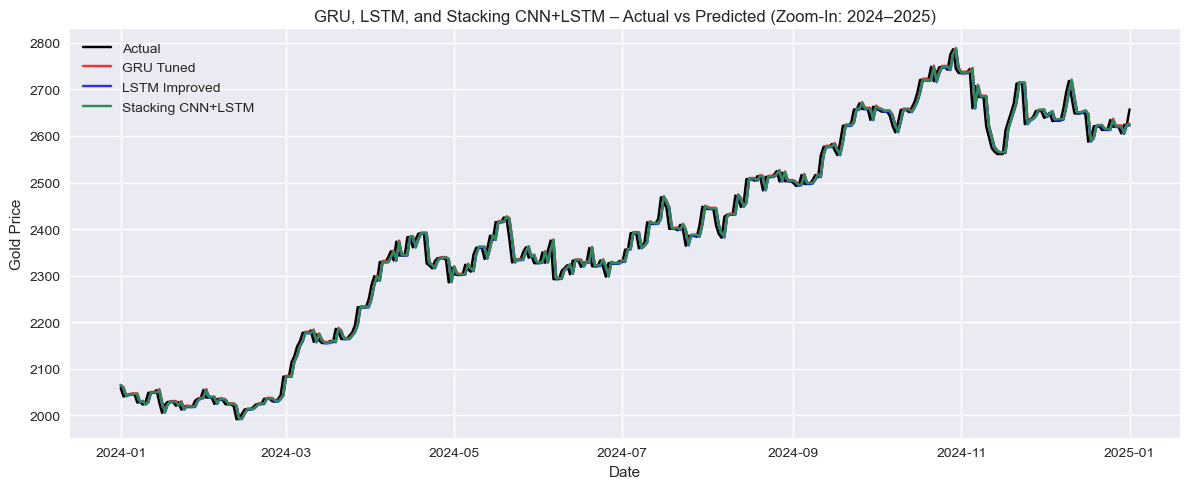

In [118]:
# =========================================================
# ZOOM-IN COMPARE - 2024 sampai 2025
# =========================================================

zoom_compare_df = plot_compare_df.loc["2024-01-01":"2025-01-01"]

plt.figure(figsize=(12, 5))
plt.plot(zoom_compare_df.index, zoom_compare_df["Actual"], color="black", label="Actual")
plt.plot(zoom_compare_df.index, zoom_compare_df["GRU Tuned"], color="red", alpha=0.8, label="GRU Tuned")
plt.plot(zoom_compare_df.index, zoom_compare_df["LSTM Improved"], color="blue", alpha=0.8, label="LSTM Improved")
plt.plot(zoom_compare_df.index, zoom_compare_df["Stacking CNN + LSTM"], color="seagreen", label="Stacking CNN+LSTM")

plt.title("GRU, LSTM, and Stacking CNN+LSTM – Actual vs Predicted (Zoom-In: 2024–2025)")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()
plt.tight_layout()
plt.show()

## Rolling walk-forward forecast: Stacking GRU+LSTM

In [121]:
# =========================================================
# SAVE BEST LSTM MODEL OBJECT
# Jalankan hanya kalau model LSTM terbaik yang aktif adalah lstm_improved
# =========================================================

lstm_best_model = lstm_improved
y_scaler_lstm_best = y_scaler_lstm
TIME_STEPS_LSTM_BEST = 20

In [204]:
# =========================================================
# FULL SEQUENCE + BASE PREDICTIONS
# Untuk Rolling Forecast Stacking GRU + LSTM
# =========================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 1. Scale seluruh fitur pakai scaler yang sama
X_all_ret_scaled_full = scaler_ret.transform(X_all_ret)

# 2. Sequence untuk GRU dengan TIME_STEPS lama
X_all_seq_gru, y_all_seq_gru = create_sequences(
    X_all_ret_scaled_full,
    y_all_ret,
    TIME_STEPS
)

# 3. Harga P_t untuk sequence GRU
P_all = reconstruct_price_from_return(y_all_price, y_all_ret)
P_all_seq_gru = P_all.iloc[TIME_STEPS:].values
index_all_seq_gru = df_fs.index[TIME_STEPS:]

# 4. Prediksi GRU tuned untuk seluruh sequence
y_pred_ret_gru_all = gru_tuned.predict(X_all_seq_gru).flatten()
y_pred_price_gru_all = P_all_seq_gru * (1.0 + y_pred_ret_gru_all)

# 5. Sequence untuk LSTM improved best
X_all_seq_lstm_best, y_all_seq_lstm_best = create_sequences(
    X_all_ret_scaled_full,
    y_all_ret,
    TIME_STEPS_LSTM_BEST
)

P_all_seq_lstm_best = P_all.iloc[TIME_STEPS_LSTM_BEST:].values
index_all_seq_lstm_best = df_fs.index[TIME_STEPS_LSTM_BEST:]

# 6. Prediksi LSTM improved best untuk seluruh sequence
y_pred_scaled_lstm_all = lstm_best_model.predict(X_all_seq_lstm_best).flatten()

y_pred_ret_lstm_all = y_scaler_lstm_best.inverse_transform(
    y_pred_scaled_lstm_all.reshape(-1, 1)
).ravel()

y_pred_price_lstm_all = P_all_seq_lstm_best * (1.0 + y_pred_ret_lstm_all)

# 7. Buat DataFrame meta-feature GRU + LSTM
series_gru_all = pd.Series(
    y_pred_price_gru_all,
    index=index_all_seq_gru,
    name="GRU_tuned"
)

series_lstm_all = pd.Series(
    y_pred_price_lstm_all,
    index=index_all_seq_lstm_best,
    name="LSTM_improved_best"
)

df_meta_all_gru_lstm = pd.concat(
    [series_gru_all, series_lstm_all],
    axis=1
).dropna()

# 8. Target aktual disamakan dengan index meta-feature
target_series_all = pd.Series(
    y_all_price.values,
    index=y_all_price.index,
    name="Actual"
)

target_all_gru_lstm = target_series_all.loc[df_meta_all_gru_lstm.index].values

print("df_meta_all_gru_lstm shape:", df_meta_all_gru_lstm.shape)
print("target_all_gru_lstm shape :", target_all_gru_lstm.shape)

display(df_meta_all_gru_lstm.head())
display(df_meta_all_gru_lstm.tail())

406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
406/406 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step
df_meta_all_gru_lstm shape: (12981, 2)
target_all_gru_lstm shape : (12981,)


,GRU_tuned,LSTM_improved_best
DATE,,
1990-02-15,413.943751,413.520568
1990-02-16,417.897512,417.483153
1990-02-17,417.897512,417.474244
1990-02-18,417.897512,417.475115
1990-02-19,416.996655,416.569805


,GRU_tuned,LSTM_improved_best
DATE,,
2025-08-26,3396.110444,3392.576653
2025-08-27,3400.654767,3396.893900
2025-08-28,3420.453600,3416.617269
2025-08-29,3451.282926,3447.359815
2025-08-30,3451.282926,3447.181632


In [206]:
# =========================================================
# ROLLING / WALK-FORWARD STACKING GRU + LSTM
# =========================================================

train_last_date = y_train_price.index[-1]

n_train_seq_roll_gru_lstm = (df_meta_all_gru_lstm.index <= train_last_date).sum()

print("Initial train size berdasarkan akhir train:", n_train_seq_roll_gru_lstm)
print("Total data untuk rolling:", len(df_meta_all_gru_lstm))

initial_train_size = n_train_seq_roll_gru_lstm
step = 5
window = 500

print(f"Step: {step} | Window: {window}")

all_preds_gru_lstm = []
all_true_gru_lstm = []
all_dates_gru_lstm = []

n_total = len(df_meta_all_gru_lstm)

for start in range(initial_train_size, n_total, step):
    end = min(start + step, n_total)

    train_start = max(0, start - window)

    X_train_meta = df_meta_all_gru_lstm.iloc[train_start:start].values
    y_train_meta = target_all_gru_lstm[train_start:start]

    X_test_meta = df_meta_all_gru_lstm.iloc[start:end].values
    y_test_meta = target_all_gru_lstm[start:end]
    dates_chunk = df_meta_all_gru_lstm.index[start:end]

    if len(X_train_meta) < 50 or len(X_test_meta) == 0:
        continue

    meta_model_roll_gru_lstm = LinearRegression()
    meta_model_roll_gru_lstm.fit(X_train_meta, y_train_meta)

    y_pred_chunk = meta_model_roll_gru_lstm.predict(X_test_meta)

    all_preds_gru_lstm.append(y_pred_chunk)
    all_true_gru_lstm.append(y_test_meta)
    all_dates_gru_lstm.append(dates_chunk)

y_true_roll_gru_lstm = np.concatenate(all_true_gru_lstm)
y_pred_roll_gru_lstm = np.concatenate(all_preds_gru_lstm)
dates_roll_gru_lstm = np.concatenate(all_dates_gru_lstm)

print("Total poin evaluasi rolling:", len(y_true_roll_gru_lstm))

metrics_stacking_roll_gru_lstm = evaluate_regression(
    y_true_roll_gru_lstm,
    y_pred_roll_gru_lstm,
    name="Stacking GRU+LSTM Rolling"
)

metrics_stacking_roll_gru_lstm

Initial train size berdasarkan akhir train: 9080
Total data untuk rolling: 12981
Step: 5 | Window: 500
Total poin evaluasi rolling: 3901
=== Stacking GRU+LSTM Rolling ===
RMSE : 14.4112
MAE  : 8.4740
MAPE : 0.0048



{'model': 'Stacking GRU+LSTM Rolling',
 'rmse': 14.411154101441038,
 'mae': 8.473961300742266,
 'mape': 0.004817886280516007}

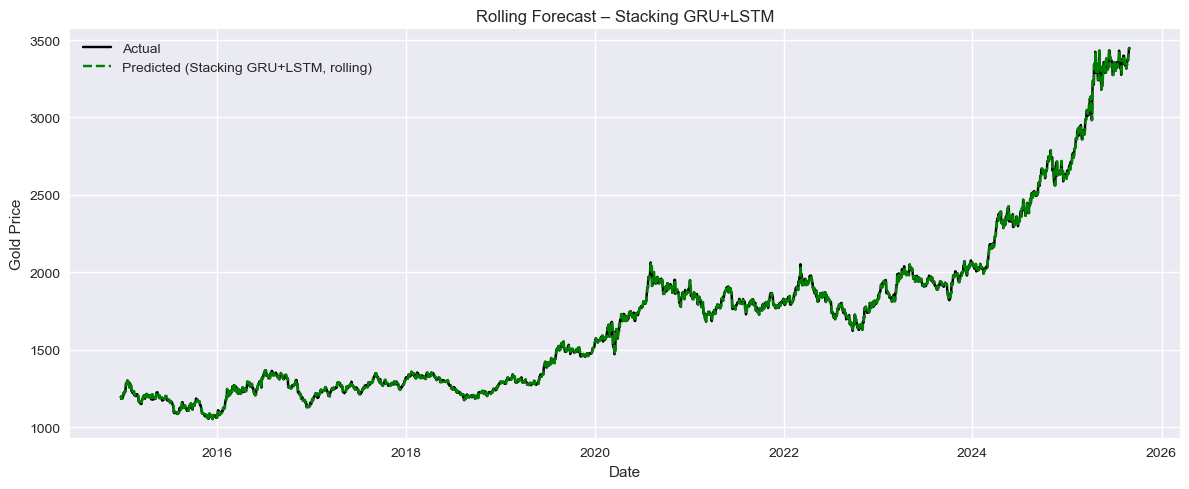

In [208]:
# =========================================================
# PLOT ROLLING FORECAST - STACKING GRU + LSTM
# =========================================================

plt.figure(figsize=(12, 5))
plt.plot(
    dates_roll_gru_lstm,
    y_true_roll_gru_lstm,
    color="black",
    label="Actual"
)
plt.plot(
    dates_roll_gru_lstm,
    y_pred_roll_gru_lstm,
    color="green",
    linestyle="--",
    label="Predicted (Stacking GRU+LSTM, rolling)"
)

plt.title("Rolling Forecast – Stacking GRU+LSTM")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()
plt.tight_layout()

plt.savefig("figure_10_rolling_gru_lstm_full.png", dpi=300, bbox_inches="tight")
plt.show()

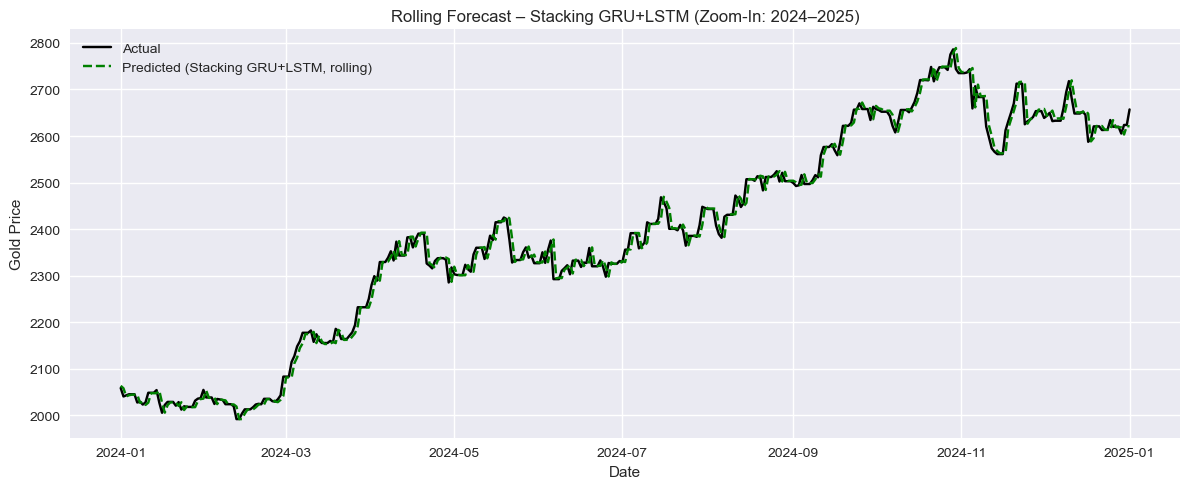

In [210]:
# =========================================================
# ZOOM-IN ROLLING FORECAST - 2024 sampai 2025
# =========================================================

dates_roll_gru_lstm_dt = pd.to_datetime(dates_roll_gru_lstm)

zoom_mask_roll_gru_lstm = (
    (dates_roll_gru_lstm_dt >= "2024-01-01") &
    (dates_roll_gru_lstm_dt <= "2025-01-01")
)

plt.figure(figsize=(12, 5))
plt.plot(
    dates_roll_gru_lstm_dt[zoom_mask_roll_gru_lstm],
    y_true_roll_gru_lstm[zoom_mask_roll_gru_lstm],
    color="black",
    label="Actual"
)
plt.plot(
    dates_roll_gru_lstm_dt[zoom_mask_roll_gru_lstm],
    y_pred_roll_gru_lstm[zoom_mask_roll_gru_lstm],
    color="green",
    linestyle="--",
    label="Predicted (Stacking GRU+LSTM, rolling)"
)

plt.title("Rolling Forecast – Stacking GRU+LSTM (Zoom-In: 2024–2025)")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()
plt.tight_layout()

plt.savefig("figure_11_rolling_gru_lstm_zoom_2024_2025.png", dpi=300, bbox_inches="tight")
plt.show()

## XAI utama: Stacking GRU+LSTM

In [217]:
# =========================================================
# XAI 1 - META-LEARNER CONTRIBUTION
# Stacking GRU + LSTM
# =========================================================

import pandas as pd
import numpy as np

coef_gru_lstm_xai_df = coef_gru_lstm_df.copy()

coef_gru_lstm_xai_df["Contribution_Percent"] = (
    coef_gru_lstm_xai_df["Relative_Contribution"] * 100
)

display(coef_gru_lstm_xai_df)

print("Interpretasi:")
for _, row in coef_gru_lstm_xai_df.iterrows():
    print(
        f"{row['Component']} berkontribusi sekitar "
        f"{row['Contribution_Percent']:.2f}% terhadap meta-learner."
    )

,Component,Coefficient,Abs_Coefficient,Relative_Contribution,Contribution_Percent
0,GRU_tuned,0.194909,0.194909,0.194819,19.481915
1,LSTM_improved_best,0.805550,0.805550,0.805181,80.518085


Interpretasi:
GRU_tuned berkontribusi sekitar 19.48% terhadap meta-learner.
LSTM_improved_best berkontribusi sekitar 80.52% terhadap meta-learner.


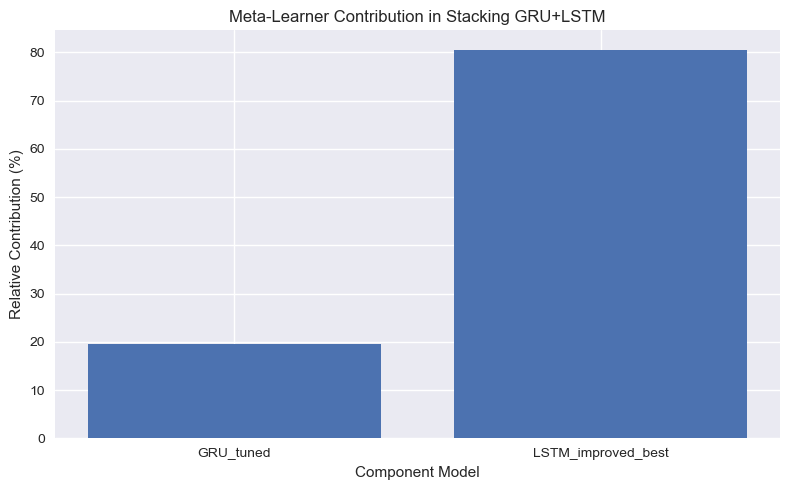

In [219]:
# =========================================================
# XAI 2 - PLOT META-LEARNER CONTRIBUTION
# Stacking GRU + LSTM
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    coef_gru_lstm_xai_df["Component"],
    coef_gru_lstm_xai_df["Contribution_Percent"]
)

plt.title("Meta-Learner Contribution in Stacking GRU+LSTM")
plt.xlabel("Component Model")
plt.ylabel("Relative Contribution (%)")
plt.tight_layout()

plt.savefig("figure_12_meta_learner_contribution_gru_lstm.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\totti\AppData\Local\Temp\ipykernel_1852\2640273405.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


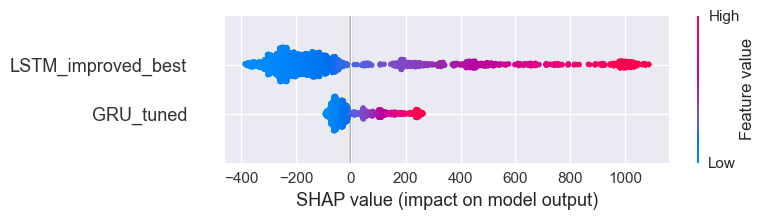

In [221]:
# =========================================================
# XAI 3 - SHAP META-LEARNER GRU+LSTM
# =========================================================

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X_meta_test_gru_lstm_df = pd.DataFrame(
    X_meta_test_gru_lstm,
    columns=["GRU_tuned", "LSTM_improved_best"]
)

explainer_meta_gru_lstm = shap.Explainer(
    stack_model_gru_lstm,
    X_meta_test_gru_lstm_df
)

shap_values_meta_gru_lstm = explainer_meta_gru_lstm(
    X_meta_test_gru_lstm_df
)

shap.summary_plot(
    shap_values_meta_gru_lstm,
    X_meta_test_gru_lstm_df,
    show=True
)

In [223]:
# =========================================================
# XAI 4 - MEAN ABSOLUTE SHAP VALUE
# META-LEARNER GRU+LSTM
# =========================================================

mean_abs_shap_meta = np.abs(shap_values_meta_gru_lstm.values).mean(axis=0)

shap_meta_importance_df = pd.DataFrame({
    "Component": X_meta_test_gru_lstm_df.columns,
    "Mean_Abs_SHAP": mean_abs_shap_meta
})

shap_meta_importance_df["Relative_Importance"] = (
    shap_meta_importance_df["Mean_Abs_SHAP"] /
    shap_meta_importance_df["Mean_Abs_SHAP"].sum()
)

shap_meta_importance_df["Relative_Importance_Percent"] = (
    shap_meta_importance_df["Relative_Importance"] * 100
)

shap_meta_importance_df = shap_meta_importance_df.sort_values(
    "Mean_Abs_SHAP",
    ascending=False
)

display(shap_meta_importance_df)

,Component,Mean_Abs_SHAP,Relative_Importance,Relative_Importance_Percent
1,LSTM_improved_best,290.838889,0.805256,80.525578
0,GRU_tuned,70.336897,0.194744,19.474422


In [140]:
# =========================================================
# XAI 5 - PERMUTATION IMPORTANCE FOR LSTM IMPROVED
# Feature-level XAI
# =========================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# Ambil feature names
feature_names = list(X_train_ret.columns)

# Data test LSTM best
X_test_lstm_xai = X_test_seq_lstm.copy()
y_test_actual_lstm_xai = y_test_price_seq_lstm.copy()
P_test_lstm_xai = P_test_seq_lstm.copy()

# Baseline prediction LSTM
y_pred_scaled_baseline = lstm_best_model.predict(X_test_lstm_xai).flatten()

y_pred_ret_baseline = y_scaler_lstm_best.inverse_transform(
    y_pred_scaled_baseline.reshape(-1, 1)
).ravel()

y_pred_price_baseline = P_test_lstm_xai * (1.0 + y_pred_ret_baseline)

baseline_rmse = np.sqrt(
    mean_squared_error(y_test_actual_lstm_xai, y_pred_price_baseline)
)

print("Baseline LSTM RMSE:", baseline_rmse)

# Permutation importance
np.random.seed(42)

perm_results = []

for feat_idx, feat_name in enumerate(feature_names):
    X_permuted = X_test_lstm_xai.copy()

    # Permutasi fitur pada seluruh timestep
    shuffled_values = X_permuted[:, :, feat_idx].copy()
    np.random.shuffle(shuffled_values)

    X_permuted[:, :, feat_idx] = shuffled_values

    y_pred_scaled_perm = lstm_best_model.predict(X_permuted, verbose=0).flatten()

    y_pred_ret_perm = y_scaler_lstm_best.inverse_transform(
        y_pred_scaled_perm.reshape(-1, 1)
    ).ravel()

    y_pred_price_perm = P_test_lstm_xai * (1.0 + y_pred_ret_perm)

    perm_rmse = np.sqrt(
        mean_squared_error(y_test_actual_lstm_xai, y_pred_price_perm)
    )

    importance = perm_rmse - baseline_rmse

    perm_results.append({
        "Feature": feat_name,
        "Baseline_RMSE": baseline_rmse,
        "Permuted_RMSE": perm_rmse,
        "Importance_RMSE_Increase": importance
    })

lstm_perm_importance_df = pd.DataFrame(perm_results)

lstm_perm_importance_df = lstm_perm_importance_df.sort_values(
    "Importance_RMSE_Increase",
    ascending=False
)

display(lstm_perm_importance_df)

61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Baseline LSTM RMSE: 18.12991320578812


,Feature,Baseline_RMSE,Permuted_RMSE,Importance_RMSE_Increase
0,GOLD_CLOSE,18.129913,18.199954,0.070041
2,SP500,18.129913,18.192978,0.063065
8,RET_PAST_1,18.129913,18.186699,0.056786
4,FED_FUNDS,18.129913,18.163424,0.033511
5,CPI_ACTUAL,18.129913,18.158979,0.029066
1,WTI,18.129913,18.153894,0.023981
12,VOL_20,18.129913,18.149384,0.019471
14,MONTH,18.129913,18.143011,0.013098
6,TREASURY_10Y,18.129913,18.142298,0.012385
9,RET_PAST_3,18.129913,18.141517,0.011604


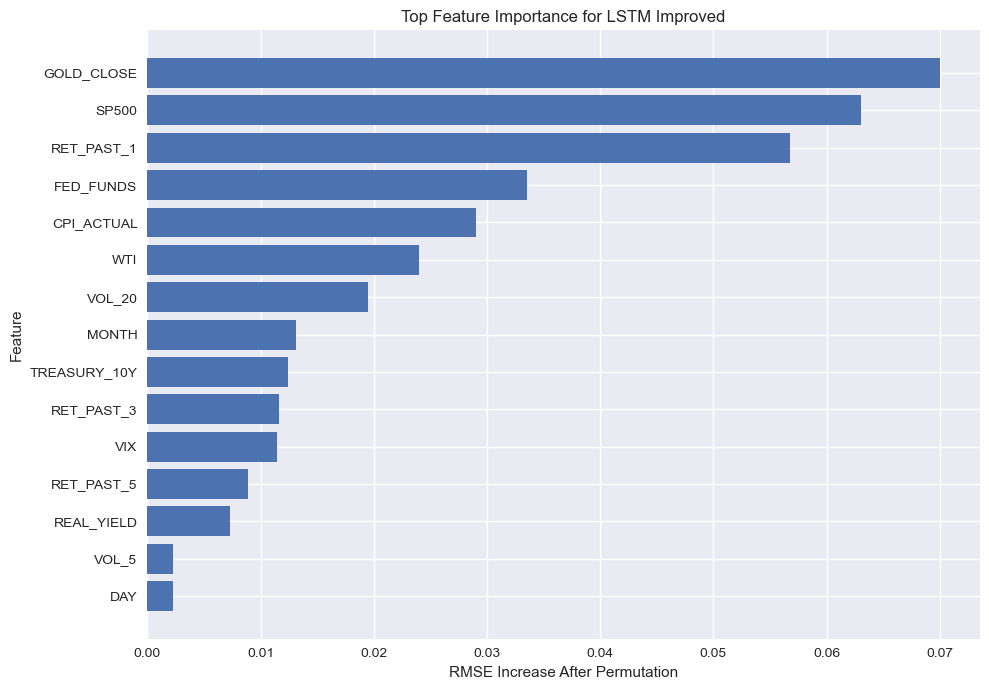

In [142]:
# =========================================================
# XAI 6 - TOP 15 LSTM FEATURE IMPORTANCE
# =========================================================

top_n = 15

top_lstm_features = lstm_perm_importance_df.head(top_n).sort_values(
    "Importance_RMSE_Increase",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_lstm_features["Feature"],
    top_lstm_features["Importance_RMSE_Increase"]
)

plt.title("Top Feature Importance for LSTM Improved")
plt.xlabel("RMSE Increase After Permutation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [225]:
# =========================================================
# EXPORT XAI RESULTS
# =========================================================

with pd.ExcelWriter("xai_results_gru_lstm.xlsx") as writer:
    coef_gru_lstm_xai_df.to_excel(
        writer,
        sheet_name="Meta_Coefficient",
        index=False
    )
    
    shap_meta_importance_df.to_excel(
        writer,
        sheet_name="Meta_SHAP",
        index=False
    )
    
    lstm_perm_importance_df.to_excel(
        writer,
        sheet_name="LSTM_Permutation",
        index=False
    )

print("XAI results saved to xai_results_gru_lstm.xlsx")

XAI results saved to xai_results_gru_lstm.xlsx


## Residual diagnostics utama: Stacking GRU+LSTM

In [228]:
# =========================================================
# RESIDUAL DIAGNOSTICS - STACKING GRU + LSTM
# Test Set
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error

residual_dates = test_index_stack_gru_lstm
actual_final = actual_stack_gru_lstm
predicted_final = pred_stack_gru_lstm

L_resid = min(
    len(residual_dates),
    len(actual_final),
    len(predicted_final)
)

residual_dates = residual_dates[-L_resid:]
actual_final = np.asarray(actual_final[-L_resid:]).reshape(-1)
predicted_final = np.asarray(predicted_final[-L_resid:]).reshape(-1)

residual_df = pd.DataFrame({
    "Actual": actual_final,
    "Predicted": predicted_final
}, index=pd.to_datetime(residual_dates))

residual_df["Residual"] = residual_df["Actual"] - residual_df["Predicted"]
residual_df["Abs_Error"] = residual_df["Residual"].abs()
residual_df["Squared_Error"] = residual_df["Residual"] ** 2
residual_df["Percentage_Error"] = residual_df["Residual"] / residual_df["Actual"]

display(residual_df.head())
display(residual_df.tail())

,Actual,Predicted,Residual,Abs_Error,Squared_Error,Percentage_Error
DATE,,,,,,
2020-05-18,1745.11,1732.773805,12.336195,12.336195,152.181714,0.007069
2020-05-19,1749.50,1745.560117,3.939883,3.939883,15.522678,0.002252
2020-05-20,1726.34,1749.980004,-23.640004,23.640004,558.849802,-0.013694
2020-05-21,1736.07,1726.812572,9.257428,9.257428,85.699974,0.005332
2020-05-22,1736.07,1736.534802,-0.464802,0.464802,0.216041,-0.000268


,Actual,Predicted,Residual,Abs_Error,Squared_Error,Percentage_Error
DATE,,,,,,
2025-08-26,3397.42,3394.277661,3.142339,3.142339,9.874295,0.000925
2025-08-27,3417.20,3398.641148,18.558852,18.558852,344.430982,0.005431
2025-08-28,3448.00,3418.388278,29.611722,29.611722,876.854100,0.008588
2025-08-29,3448.00,3449.161847,-1.161847,1.161847,1.349889,-0.000337
2025-08-30,3448.00,3449.018312,-1.018312,1.018312,1.036959,-0.000295


In [149]:
# =========================================================
# RESIDUAL SUMMARY STATISTICS
# =========================================================

residual_values = residual_df["Residual"].values

residual_summary = pd.DataFrame({
    "Metric": [
        "Mean Residual",
        "Median Residual",
        "Std Residual",
        "Min Residual",
        "Max Residual",
        "Skewness",
        "Kurtosis",
        "RMSE",
        "MAE",
        "MAPE"
    ],
    "Value": [
        residual_df["Residual"].mean(),
        residual_df["Residual"].median(),
        residual_df["Residual"].std(),
        residual_df["Residual"].min(),
        residual_df["Residual"].max(),
        residual_df["Residual"].skew(),
        residual_df["Residual"].kurtosis(),
        np.sqrt(mean_squared_error(residual_df["Actual"], residual_df["Predicted"])),
        mean_absolute_error(residual_df["Actual"], residual_df["Predicted"]),
        np.mean(np.abs(residual_df["Percentage_Error"]))
    ]
})

display(residual_summary)

,Metric,Value
0,Mean Residual,0.492006
1,Median Residual,-0.326246
2,Std Residual,18.090725
3,Min Residual,-116.711674
4,Max Residual,114.858856
5,Skewness,-0.130859
6,Kurtosis,6.634540
7,RMSE,18.092731
8,MAE,11.029770
9,MAPE,0.005105


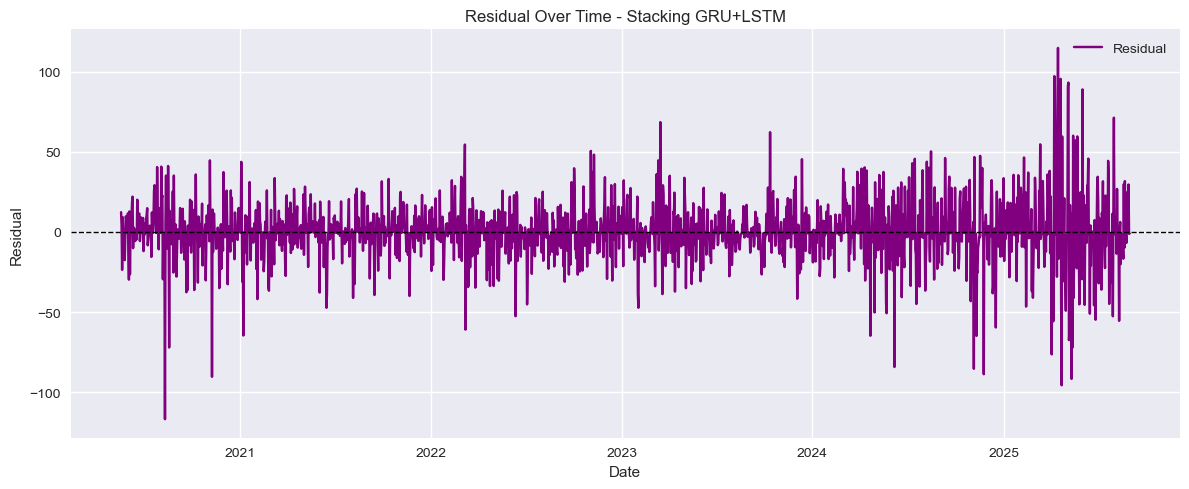

In [230]:
# =========================================================
# PLOT 1 - RESIDUAL OVER TIME
# =========================================================

plt.figure(figsize=(12, 5))
plt.plot(
    residual_df.index,
    residual_df["Residual"],
    color="purple",
    label="Residual"
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("Residual Over Time - Stacking GRU+LSTM")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.tight_layout()
plt.show()

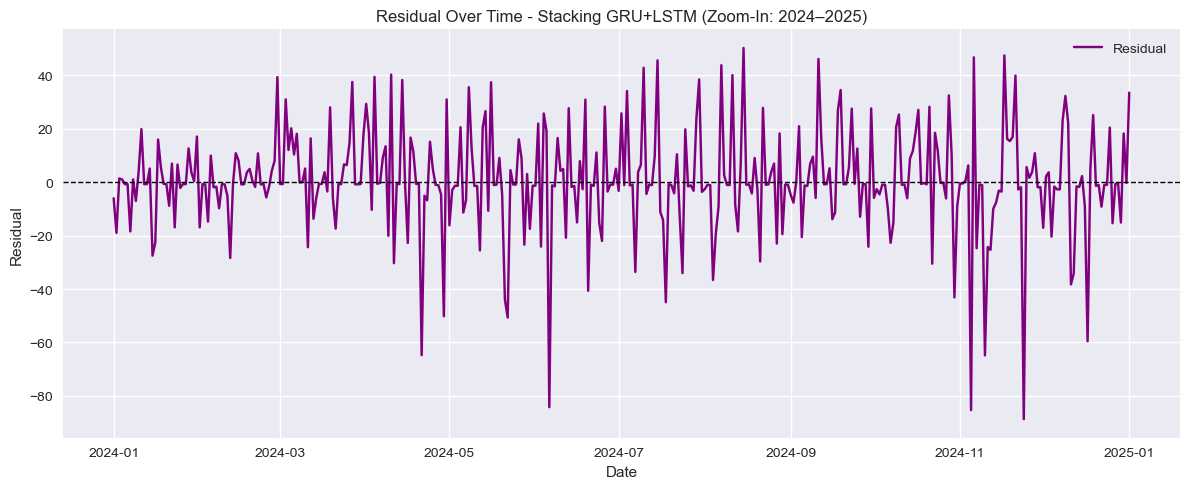

In [234]:
# =========================================================
# PLOT 2 - RESIDUAL OVER TIME ZOOM-IN 2024-2025
# =========================================================

residual_zoom_df = residual_df.loc["2024-01-01":"2025-01-01"]

plt.figure(figsize=(12, 5))
plt.plot(
    residual_zoom_df.index,
    residual_zoom_df["Residual"],
    color="purple",
    label="Residual"
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("Residual Over Time - Stacking GRU+LSTM (Zoom-In: 2024–2025)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.tight_layout()
plt.show()

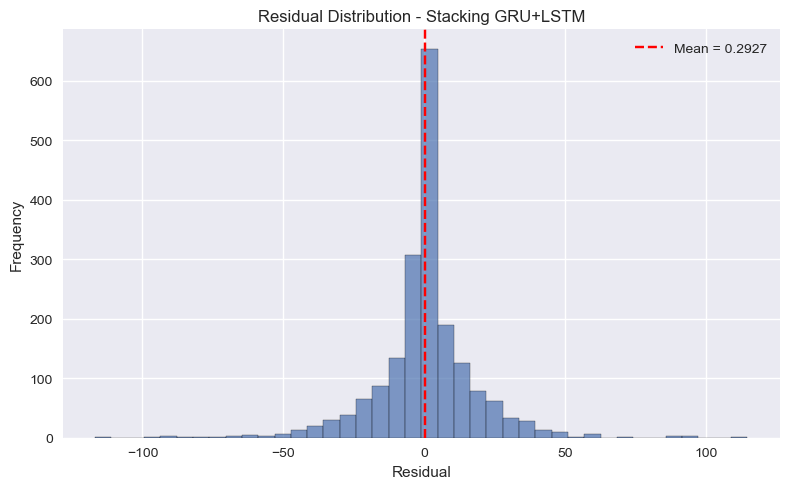

In [236]:
# =========================================================
# PLOT 3 - RESIDUAL DISTRIBUTION
# =========================================================

plt.figure(figsize=(8, 5))
plt.hist(
    residual_df["Residual"],
    bins=40,
    edgecolor="black",
    alpha=0.7
)

plt.axvline(
    residual_df["Residual"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean = {residual_df['Residual'].mean():.4f}"
)

plt.title("Residual Distribution - Stacking GRU+LSTM")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

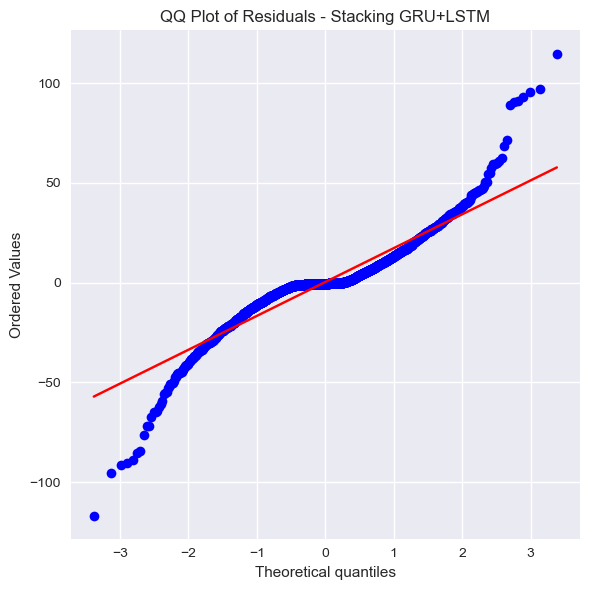

In [238]:
# =========================================================
# PLOT 4 - QQ PLOT RESIDUAL
# =========================================================

plt.figure(figsize=(6, 6))
stats.probplot(
    residual_df["Residual"],
    dist="norm",
    plot=plt
)

plt.title("QQ Plot of Residuals - Stacking GRU+LSTM")
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

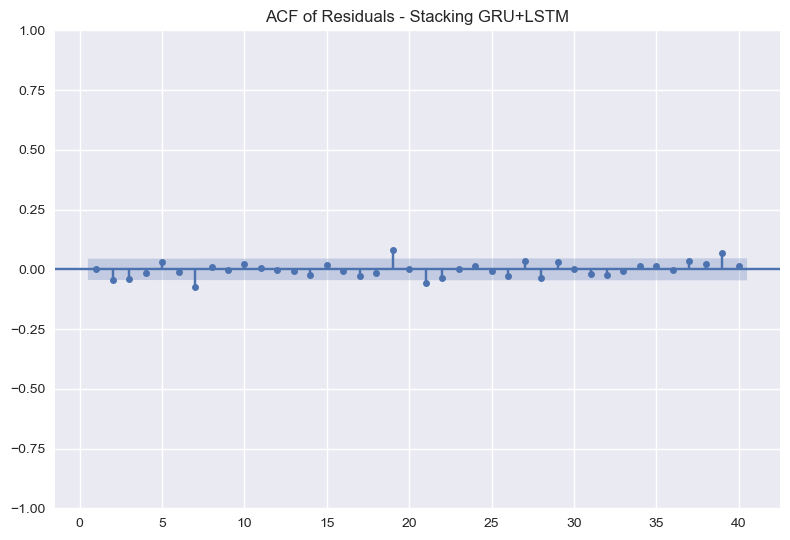

In [240]:
# =========================================================
# PLOT 5 - ACF RESIDUAL
# =========================================================

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 5))
plot_acf(
    residual_df["Residual"],
    lags=40,
    zero=False
)
plt.title("ACF of Residuals - Stacking GRU+LSTM")
plt.tight_layout()
plt.show()

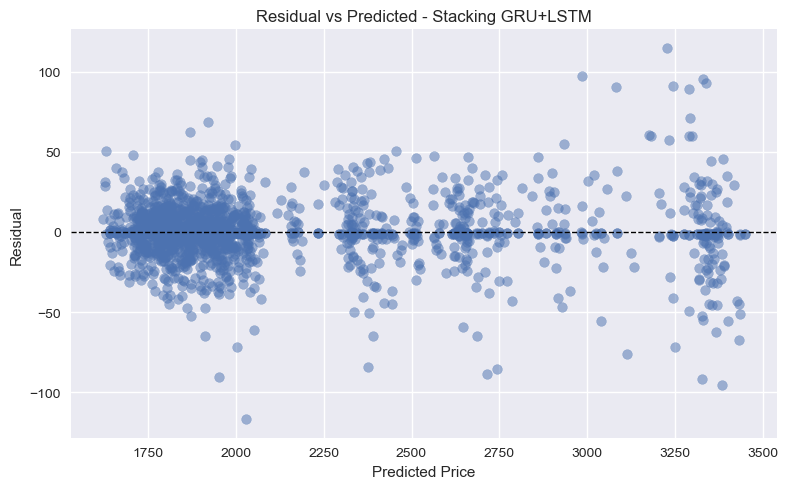

In [242]:
# =========================================================
# PLOT 6 - RESIDUAL VS PREDICTED
# =========================================================

plt.figure(figsize=(8, 5))
plt.scatter(
    residual_df["Predicted"],
    residual_df["Residual"],
    alpha=0.5
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("Residual vs Predicted - Stacking GRU+LSTM")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

In [163]:
# =========================================================
# STATISTICAL TESTS FOR RESIDUAL DIAGNOSTICS
# Ljung-Box, Jarque-Bera, ARCH
# =========================================================

from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera

# Ljung-Box test
ljung_box_result = acorr_ljungbox(
    residual_df["Residual"],
    lags=[10, 20, 30],
    return_df=True
)

# Jarque-Bera normality test
jb_stat, jb_pvalue, skewness, kurtosis = jarque_bera(
    residual_df["Residual"]
)

# ARCH test
arch_stat, arch_pvalue, _, _ = het_arch(
    residual_df["Residual"]
)

print("=== Ljung-Box Test ===")
display(ljung_box_result)

print("\n=== Jarque-Bera Test ===")
print(f"JB Statistic : {jb_stat:.4f}")
print(f"JB p-value   : {jb_pvalue:.6f}")
print(f"Skewness     : {skewness:.4f}")
print(f"Kurtosis     : {kurtosis:.4f}")

print("\n=== ARCH Test ===")
print(f"ARCH Statistic : {arch_stat:.4f}")
print(f"ARCH p-value   : {arch_pvalue:.6f}")

=== Ljung-Box Test ===


,lb_stat,lb_pvalue
10,21.360111,0.018718
20,37.694782,0.009647
30,54.516267,0.004025



=== Jarque-Bera Test ===
JB Statistic : 3525.4368
JB p-value   : 0.000000
Skewness     : -0.1308
Kurtosis     : 9.6143

=== ARCH Test ===
ARCH Statistic : 249.1027
ARCH p-value   : 0.000000


In [244]:
# =========================================================
# EXPORT RESIDUAL DIAGNOSTICS
# =========================================================

with pd.ExcelWriter("residual_diagnostics_gru_lstm.xlsx") as writer:
    residual_df.to_excel(
        writer,
        sheet_name="Residual_Data"
    )
    
    residual_summary.to_excel(
        writer,
        sheet_name="Residual_Summary",
        index=False
    )
    
    ljung_box_result.to_excel(
        writer,
        sheet_name="Ljung_Box"
    )

print("Residual diagnostics saved to residual_diagnostics_gru_lstm.xlsx")

Residual diagnostics saved to residual_diagnostics_gru_lstm.xlsx


## Diebold-Mariano test: GRU+LSTM vs GRU+CNN

In [168]:
# =========================================================
# DIEBOLD-MARIANO TEST FUNCTION
# =========================================================

import numpy as np
import pandas as pd
from scipy import stats

def diebold_mariano_test(
    actual,
    pred_1,
    pred_2,
    loss="squared",
    h=1,
    alternative="two_sided"
):
    """
    Diebold-Mariano test for comparing predictive accuracy.

    actual : array-like
        Actual values.
    pred_1 : array-like
        Prediction from model 1.
    pred_2 : array-like
        Prediction from model 2.
    loss : str
        'squared' for squared error loss, 'absolute' for absolute error loss.
    h : int
        Forecast horizon. Use h=1 for one-step-ahead forecast.
    alternative : str
        'two_sided', 'less', or 'greater'.

    Interpretation:
    loss differential d = loss_model_1 - loss_model_2

    If mean(d) < 0:
        Model 1 has lower average loss than Model 2.
    """

    actual = np.asarray(actual).reshape(-1)
    pred_1 = np.asarray(pred_1).reshape(-1)
    pred_2 = np.asarray(pred_2).reshape(-1)

    n = min(len(actual), len(pred_1), len(pred_2))

    actual = actual[-n:]
    pred_1 = pred_1[-n:]
    pred_2 = pred_2[-n:]

    e1 = actual - pred_1
    e2 = actual - pred_2

    if loss == "squared":
        d = e1**2 - e2**2
    elif loss == "absolute":
        d = np.abs(e1) - np.abs(e2)
    else:
        raise ValueError("loss must be either 'squared' or 'absolute'")

    mean_d = np.mean(d)

    # Newey-West style variance for h-step forecast
    gamma = []
    for lag in range(h):
        if lag == 0:
            gamma.append(np.var(d, ddof=1))
        else:
            cov = np.cov(d[lag:], d[:-lag], ddof=1)[0, 1]
            gamma.append(cov)

    var_d = gamma[0] + 2 * sum(gamma[1:])
    dm_stat = mean_d / np.sqrt(var_d / n)

    # Harvey-Leybourne-Newbold small sample correction
    correction = np.sqrt((n + 1 - 2*h + (h * (h - 1) / n)) / n)
    dm_stat_corrected = dm_stat * correction

    if alternative == "two_sided":
        p_value = 2 * (1 - stats.t.cdf(abs(dm_stat_corrected), df=n-1))
    elif alternative == "less":
        p_value = stats.t.cdf(dm_stat_corrected, df=n-1)
    elif alternative == "greater":
        p_value = 1 - stats.t.cdf(dm_stat_corrected, df=n-1)
    else:
        raise ValueError("alternative must be 'two_sided', 'less', or 'greater'")

    result = {
        "loss": loss,
        "n_obs": n,
        "mean_loss_diff_model1_minus_model2": mean_d,
        "dm_stat": dm_stat_corrected,
        "p_value": p_value
    }

    return result

In [247]:
# =========================================================
# DIEBOLD-MARIANO TEST
# GRU+LSTM Rolling vs GRU+CNN Rolling
# =========================================================

gru_cnn_roll_df = pd.DataFrame({
    "Actual_GRU_CNN": y_true_roll,
    "Pred_GRU_CNN": y_pred_roll
}, index=pd.to_datetime(dates_roll))

gru_lstm_roll_df = pd.DataFrame({
    "Actual_GRU_LSTM": y_true_roll_gru_lstm,
    "Pred_GRU_LSTM": y_pred_roll_gru_lstm
}, index=pd.to_datetime(dates_roll_gru_lstm))

dm_roll_df = pd.concat(
    [gru_cnn_roll_df, gru_lstm_roll_df],
    axis=1
).dropna()

display(dm_roll_df.head())
display(dm_roll_df.tail())

print("Jumlah observasi DM test:", len(dm_roll_df))

actual_dm = dm_roll_df["Actual_GRU_LSTM"].values

pred_gru_lstm_dm = dm_roll_df["Pred_GRU_LSTM"].values
pred_gru_cnn_dm = dm_roll_df["Pred_GRU_CNN"].values

,Actual_GRU_CNN,Pred_GRU_CNN,Actual_GRU_LSTM,Pred_GRU_LSTM
2014-12-26,1195.40,1198.821050,1195.40,1196.621964
2014-12-27,1195.40,1194.017269,1195.40,1196.390720
2014-12-28,1183.10,1197.982395,1183.10,1196.281971
2014-12-29,1200.24,1185.154783,1200.24,1184.013845
2014-12-30,1183.95,1204.802239,1183.95,1200.888881


,Actual_GRU_CNN,Pred_GRU_CNN,Actual_GRU_LSTM,Pred_GRU_LSTM
2025-08-26,3397.42,3394.872183,3397.42,3393.924414
2025-08-27,3417.20,3400.255979,3417.20,3398.127908
2025-08-28,3448.00,3418.205946,3448.00,3417.801702
2025-08-29,3448.00,3447.662716,3448.00,3448.482052
2025-08-30,3448.00,3449.587973,3448.00,3448.821145


Jumlah observasi DM test: 3901


In [249]:
# =========================================================
# DM TEST - SQUARED ERROR LOSS
# Model 1: GRU+LSTM
# Model 2: GRU+CNN
# =========================================================

dm_squared_result = diebold_mariano_test(
    actual=actual_dm,
    pred_1=pred_gru_lstm_dm,
    pred_2=pred_gru_cnn_dm,
    loss="squared",
    h=1,
    alternative="two_sided"
)

dm_squared_result

{'loss': 'squared',
 'n_obs': 3901,
 'mean_loss_diff_model1_minus_model2': -1.3321724081179158,
 'dm_stat': -1.380844397928705,
 'p_value': 0.1674059308614011}

In [251]:
# =========================================================
# DM TEST - ABSOLUTE ERROR LOSS
# Model 1: GRU+LSTM
# Model 2: GRU+CNN
# =========================================================

dm_absolute_result = diebold_mariano_test(
    actual=actual_dm,
    pred_1=pred_gru_lstm_dm,
    pred_2=pred_gru_cnn_dm,
    loss="absolute",
    h=1,
    alternative="two_sided"
)

dm_absolute_result

{'loss': 'absolute',
 'n_obs': 3901,
 'mean_loss_diff_model1_minus_model2': -0.07070839606914009,
 'dm_stat': -2.734782668290877,
 'p_value': 0.006270362633609805}

In [253]:
# =========================================================
# DIEBOLD-MARIANO SUMMARY TABLE
# =========================================================

dm_summary_df = pd.DataFrame([
    {
        "Comparison": "GRU+LSTM vs GRU+CNN",
        "Loss_Function": "Squared Error",
        "Mean_Loss_Diff": dm_squared_result["mean_loss_diff_model1_minus_model2"],
        "DM_Statistic": dm_squared_result["dm_stat"],
        "P_Value": dm_squared_result["p_value"],
        "Conclusion": (
            "Significant" if dm_squared_result["p_value"] < 0.05 
            else "Not Significant"
        )
    },
    {
        "Comparison": "GRU+LSTM vs GRU+CNN",
        "Loss_Function": "Absolute Error",
        "Mean_Loss_Diff": dm_absolute_result["mean_loss_diff_model1_minus_model2"],
        "DM_Statistic": dm_absolute_result["dm_stat"],
        "P_Value": dm_absolute_result["p_value"],
        "Conclusion": (
            "Significant" if dm_absolute_result["p_value"] < 0.05 
            else "Not Significant"
        )
    }
])

display(dm_summary_df)

,Comparison,Loss_Function,Mean_Loss_Diff,DM_Statistic,P_Value,Conclusion
0,GRU+LSTM vs GRU+CNN,Squared Error,-1.332172,-1.380844,0.167406,Not Significant
1,GRU+LSTM vs GRU+CNN,Absolute Error,-0.070708,-2.734783,0.006270,Significant


## Kesimpulan utama

In [255]:
# =========================================================
# FINAL CONCLUSION SUMMARY
# =========================================================

print("Final model:", final_model_name)
print("Test RMSE:", metrics_final_stack_test["rmse"])
print("Test MAE :", metrics_final_stack_test["mae"])
print("Test MAPE:", metrics_final_stack_test["mape"])
print("Rolling RMSE:", metrics_stacking_roll_gru_lstm["rmse"])
print("Rolling MAE :", metrics_stacking_roll_gru_lstm["mae"])
print("Rolling MAPE:", metrics_stacking_roll_gru_lstm["mape"])
print("DM squared p-value :", dm_squared_result["p_value"])
print("DM absolute p-value:", dm_absolute_result["p_value"])

final_summary_df = pd.DataFrame([
    {
        "Final_Model": final_model_name,
        "Test_RMSE": metrics_final_stack_test["rmse"],
        "Test_MAE": metrics_final_stack_test["mae"],
        "Test_MAPE": metrics_final_stack_test["mape"],
        "Rolling_RMSE": metrics_stacking_roll_gru_lstm["rmse"],
        "Rolling_MAE": metrics_stacking_roll_gru_lstm["mae"],
        "Rolling_MAPE": metrics_stacking_roll_gru_lstm["mape"],
        "DM_Squared_P_Value": dm_squared_result["p_value"],
        "DM_Absolute_P_Value": dm_absolute_result["p_value"],
    }
])

display(final_summary_df)

Final model: Stacking GRU + LSTM
Test RMSE: 18.08218973163471
Test MAE : 10.983953769276026
Test MAPE: 0.0050832389085740054
Rolling RMSE: 14.411154101441038
Rolling MAE : 8.473961300742266
Rolling MAPE: 0.004817886280516007
DM squared p-value : 0.1674059308614011
DM absolute p-value: 0.006270362633609805


,Final_Model,Test_RMSE,Test_MAE,Test_MAPE,Rolling_RMSE,Rolling_MAE,Rolling_MAPE,DM_Squared_P_Value,DM_Absolute_P_Value
0,Stacking GRU + LSTM,18.08219,10.983954,0.005083,14.411154,8.473961,0.004818,0.167406,0.00627


In [257]:
# =========================================================
# RESIDUAL DIAGNOSTICS - FINAL STACKING GRU + LSTM
# =========================================================

import numpy as np
import pandas as pd

# Pakai final model yang sudah disimpan
actual_final = np.asarray(y_test_actual_final_stack).reshape(-1)
predicted_final = np.asarray(y_test_pred_price_final_stack).reshape(-1)

L_resid = min(len(actual_final), len(predicted_final))

actual_final = actual_final[-L_resid:]
predicted_final = predicted_final[-L_resid:]

residual_df = pd.DataFrame({
    "Actual": actual_final,
    "Predicted": predicted_final
})

residual_df["Residual"] = residual_df["Actual"] - residual_df["Predicted"]
residual_df["Abs_Error"] = residual_df["Residual"].abs()
residual_df["Squared_Error"] = residual_df["Residual"] ** 2
residual_df["Percentage_Error"] = residual_df["Residual"] / residual_df["Actual"]

residual_summary = pd.DataFrame({
    "Metric": [
        "Mean Residual",
        "Median Residual",
        "Std Residual",
        "Min Residual",
        "Max Residual",
        "Skewness",
        "Kurtosis",
        "RMSE",
        "MAE",
        "MAPE"
    ],
    "Value": [
        residual_df["Residual"].mean(),
        residual_df["Residual"].median(),
        residual_df["Residual"].std(),
        residual_df["Residual"].min(),
        residual_df["Residual"].max(),
        residual_df["Residual"].skew(),
        residual_df["Residual"].kurtosis(),
        metrics_final_stack_test["rmse"],
        metrics_final_stack_test["mae"],
        metrics_final_stack_test["mape"]
    ]
})

display(residual_summary)

,Metric,Value
0,Mean Residual,0.292650
1,Median Residual,-0.503347
2,Std Residual,18.084505
3,Min Residual,-116.805716
4,Max Residual,114.822790
5,Skewness,-0.095788
6,Kurtosis,6.678062
7,RMSE,18.082190
8,MAE,10.983954
9,MAPE,0.005083
